In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
from sionnart import SionnaRT
from mobility import SionnaMobility

/home/aung/anaconda3/envs/6G/lib/python3.12/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()
pybullet build time: Jan  6 2026 23:44:17


In [3]:
ASSETS = "/home/aung/code/docte6g/assets"

In [4]:
def _advance_wp(name, waypoints, idx_map):
    wps = waypoints[name]
    idx = idx_map[name]
    if idx < len(wps):
        idx_map[name] += 1
        return wps[idx]
    return wps[-1]

In [5]:

def _match_detections_to_gt(dets, gt, match_threshold):
    """One-to-one thresholded Hungarian matching for detection metrics."""
    dets = np.asarray(dets, dtype=float) if len(dets) else np.empty((0, 3))
    gt = np.asarray(gt, dtype=float) if len(gt) else np.empty((0, 3))
    n_det, n_gt = len(dets), len(gt)
    if n_det == 0 or n_gt == 0:
        return 0, n_det, n_gt, []

    from scipy.optimize import linear_sum_assignment

    dist = np.linalg.norm(dets[:, None, :] - gt[None, :, :], axis=-1)
    rows, cols = linear_sum_assignment(dist)
    pairs = [(int(i), int(j), float(dist[i, j])) for i, j in zip(rows, cols) if dist[i, j] <= match_threshold]
    tp = len(pairs)
    fp = n_det - tp
    fn = n_gt - tp
    return tp, fp, fn, pairs


def _gt_from_trajectories_at_time(trajectories, agent_names, dt, t):
    step = int(round(t / dt))
    return [trajectories[n][step] for n in agent_names if step < len(trajectories[n])]


def compute_isac_metrics(detections, trajectories, agent_names, dt, match_threshold=5.0):
    """
    Evaluate detections against ground truth with one-to-one Hungarian matching.

    Returns (dr, miss_rate, fp_per_frame, frame_stats). DR is recall = TP/GT.
    False positives are detections that do not match any ground-truth UE within
    ``match_threshold``. Object detection has no natural true-negative count here,
    so FP/frame is reported instead of a binary-classification FPR.
    """
    frame_stats = []
    total_gt = total_tp = total_fp = 0

    for frame in detections:
        t = frame["time"]
        gt = _gt_from_trajectories_at_time(trajectories, agent_names, dt, t)
        dets = frame["positions"] if frame["positions"] else []
        tp, fp, fn, pairs = _match_detections_to_gt(dets, gt, match_threshold)

        n_gt = len(gt)
        total_gt += n_gt
        total_tp += tp
        total_fp += fp
        frame_dr = tp / n_gt if n_gt else 0.0
        frame_stats.append((t, frame_dr, float(fp)))

    dr = total_tp / total_gt if total_gt else 0.0
    fp_per_frame = total_fp / len(detections) if detections else 0.0
    return dr, 1.0 - dr, fp_per_frame, frame_stats


def plot_isac_metrics(frame_stats, dr, miss, fp_per_frame, dt, title="ISAC Metrics"):
    ts = [f[0] for f in frame_stats]
    drs = [f[1] for f in frame_stats]
    fps = [f[2] for f in frame_stats]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

    ax1.bar(ts, drs, width=dt * 0.8, color="steelblue")
    ax1.axhline(dr, color="navy", linestyle="--", linewidth=1.5,
                label=f"mean DR = {dr:.2f}")
    ax1.set_ylim(0, 1.15)
    ax1.set_ylabel("detection rate")
    ax1.set_title(f"{title}  |  DR = {dr:.2f}   Miss = {miss:.2f}   FP/frame = {fp_per_frame:.2f}")
    ax1.legend()
    ax1.grid(True, axis="y")

    ax2.bar(ts, fps, width=dt * 0.8, color="crimson")
    ax2.set_ylabel("# false positives")
    ax2.set_xlabel("time (s)")
    ax2.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax2.grid(True, axis="y")

    plt.tight_layout()
    plt.show()


# Free Space

### Configurations

In [6]:
_UE_SPEED = 2.0
_INTERVAL = 0.5
_MTI_THRESHOLD = (_UE_SPEED * _INTERVAL / 2) - 0.1

UE_START = [
    [-5.0, 10.0, 1.5],
    [0.0, 15.0, 1.5],
    [5.0, 20.0, 1.5]
]

radio_settings = {
    # NR
    "scene": f"{ASSETS}/scenes/free_space/free_space.xml",
    "carrier_frequency": 3.5e9,
    "subcarrier_spacing": 30000,
    "num_subcarriers": 3276,
    "tx_num_rows": 8, "tx_num_rows": 8,
    "rx_num_rows": 2, "rx_num_rows": 2,
    "pattern": "tr38901",
    "polarization": "VH",
    "tx_locations": [[0.0, 0.0, 10.0]],
    "tx_names": ["gNB"],
    "tx_ids": [0],
    "tx_power": 46.0,
    "rx_locations": UE_START,
    "rx_names": ["ue_1", "ue_2", "ue_3"],
    "rx_ids": [1, 2, 3],
    "rx_speed": [_UE_SPEED] * 3,
    "rx_mesh": f"{ASSETS}/objects/iw_hub/iw_hub.ply",
    "rx_update_interval": _INTERVAL,
    "simulation_duration": 15.0,

    # ISAC
    "enable_situation_awareness": True,
    "rx_type_path": f"{ASSETS}/objects/iw_hub/iw_hub.ply",
    "isac_min_power": 1e-25,
    "isac_eps_cluster": 1.5,
    "isac_mti_dist_thresh": _MTI_THRESHOLD,
    "isac_rx_scattering_coefficient": 0.5,
    "isac_min_displacement": 0.3,
    "isac_beamwidth_deg": 20.0,
    "isac_max_depth": 3,
    "isac_diffuse_reflection": True,
    "isac_samples_per_src": 2_000_000,
    "isac_single_bounce_only": True,
    "isac_mti_warmup_frames": 0,
    "isac_tracker_max_tracks": len(UE_START),
}

mobility_settings = {
    "scene": f"{ASSETS}/scenes/free_space/free_space.obj",
    "tx_locations": radio_settings["tx_locations"],
    "tx_names": radio_settings["tx_names"],
    "tx_ids": radio_settings["tx_ids"],
    "tx_modes": ["CONSTANT_POSITION"],
    "tx_power": radio_settings["tx_power"],
    "rx_locations": [[p[0], p[1], 0.0] for p in UE_START],
    "rx_names": radio_settings["rx_names"],
    "rx_ids": radio_settings["rx_ids"],
    "rx_modes": ["WAYPOINT"] * 3,
    "rx_speed": radio_settings["rx_speed"],
    "rx_mesh": f"{ASSETS}/objects/iw_hub/iw_hub.obj"
}


### Instantiation

In [7]:
sionnart = SionnaRT()
sionnart.initialize(radio_settings)

mobility = SionnaMobility()
mobility.initialize(mobility_settings)

assert sionnart.enable_SA, "ISAC must be enabled"
print("ISAC calibration:", sionnart.calib)

ISAC calibration: {'eps_cluster': 1.5, 'z_min': 0.884299099445343, 'z_max': 2.347102701663971, 'min_power': 1e-25, 'bbox_size': array([1.43085217, 0.65968287, 0.2314018 ])}


### Simulation

In [8]:
UE_WAYPOINTS = {
    "ue_1": [[-5.0, 10.0], [ 5.0, 14.0], [-5.0, 18.0], [ 5.0, 22.0], [ 0.0, 26.0]],
    "ue_2": [[ 0.0, 15.0], [-8.0, 19.0], [ 2.0, 23.0], [-5.0, 27.0], [ 0.0, 30.0]],
    "ue_3": [[ 5.0, 20.0], [-3.0, 24.0], [ 7.0, 27.0], [ 0.0, 30.0], [ 5.0, 33.0]],
}

ues               = radio_settings["rx_names"]
rx_height         = 1.5
trajectories      = {name: [] for name in ues}
rx_update_interval = float(radio_settings["rx_update_interval"])
num_steps          = max(1, int(float(radio_settings["simulation_duration"]) / rx_update_interval))
wp_idx             = {name: 1 for name in ues}

current_dest = {name: UE_WAYPOINTS[name][1] for name in ues}
for name in ues:
    d = current_dest[name]
    mobility.set_destination(name, [d[0], d[1], 0.0])

all_records = []
for step in range(num_steps):
    timestamp = step * rx_update_interval
    for name in ues:
        pos = mobility.update_position(name, timestamp)
        if pos is not None:
            sionnart.update_position(name, [pos[0], pos[1], rx_height])
            trajectories[name].append([pos[0], pos[1], rx_height])
            dest = current_dest[name]
            if np.hypot(pos[0] - dest[0], pos[1] - dest[1]) < 1.5:
                nxt = _advance_wp(name, UE_WAYPOINTS, wp_idx)
                mobility.set_destination(name, [nxt[0], nxt[1], 0.0])
                current_dest[name] = nxt
    records = sionnart.perform_calculation(timestamp)
    all_records.extend(records)

perf       = sionnart.get_perf_stats()
detections = sionnart.get_detected_objects()
print(f"Propagation records : {len(all_records)}")
print(f"Detection frames    : {len(detections)}")
print(f"Frames with tracks  : {sum(1 for d in detections if d['positions'])}")
print(f"Path-solve seconds  : {perf.get('python_path_solve_seconds', 0.0):.3f}")
print(f"ISAC pre-pass sec   : {perf.get('python_isac_pre_seconds', 0.0):.3f}")

Propagation records : 300
Detection frames    : 30
Frames with tracks  : 28
Path-solve seconds  : 0.443
ISAC pre-pass sec   : 0.578


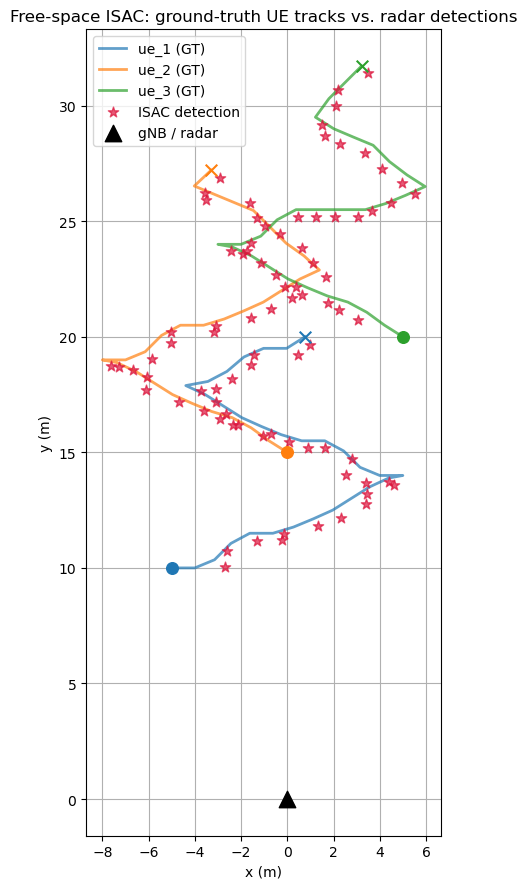

In [9]:
colors = {"ue_1": "tab:blue", "ue_2": "tab:orange", "ue_3": "tab:green"}

fig, ax = plt.subplots(figsize=(9, 9))

# Ground-truth trajectories
for name, pts in trajectories.items():
    if not pts:
        continue
    pts = np.array(pts)
    ax.plot(pts[:, 0], pts[:, 1], color=colors.get(name, "gray"),
            label=f"{name} (GT)", linewidth=2, alpha=0.7)
    ax.scatter(pts[0, 0], pts[0, 1], color=colors.get(name, "gray"),
               marker="o", s=70, zorder=5)
    ax.scatter(pts[-1, 0], pts[-1, 1], color=colors.get(name, "gray"),
               marker="x", s=70, zorder=5)

# ISAC detections across all frames
det_xy = []
for frame in detections:
    for p in frame["positions"]:
        det_xy.append(p[:2])
if det_xy:
    det_xy = np.array(det_xy)
    ax.scatter(det_xy[:, 0], det_xy[:, 1], marker="*", color="crimson",
               s=60, alpha=0.7, label="ISAC detection", zorder=4)

gnb = radio_settings["tx_locations"][0]
ax.scatter(gnb[0], gnb[1], color="black", marker="^", s=140,
           zorder=6, label="gNB / radar")

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Free-space ISAC: ground-truth UE tracks vs. radar detections")
ax.legend(loc="best")
ax.grid(True)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

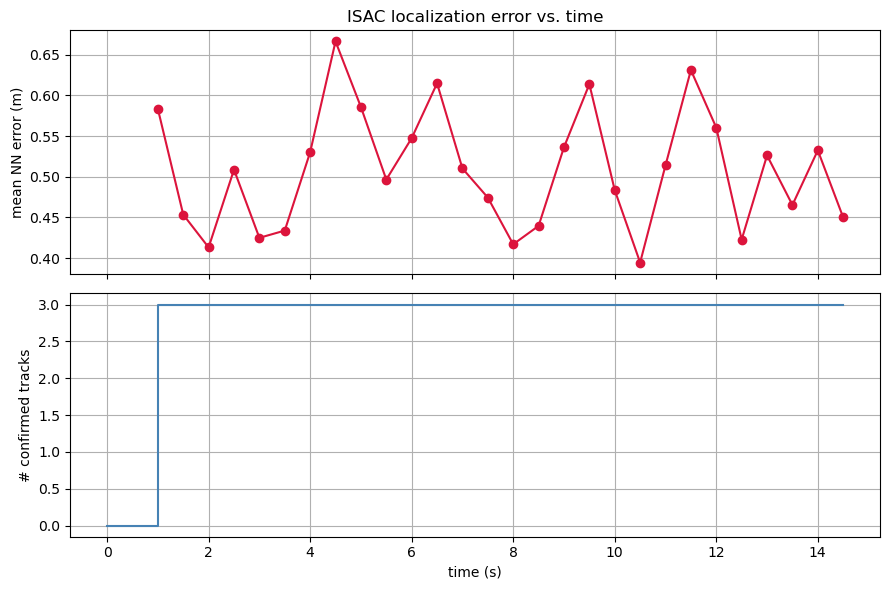

In [10]:
times, errors, counts = [], [], []
for frame in detections:
    t = frame["time"]
    step = int(round(t / rx_update_interval))
    gt = []
    for name in ues:
        if step < len(trajectories[name]):
            gt.append(trajectories[name][step])
    if not gt or not frame["positions"]:
        times.append(t); errors.append(np.nan); counts.append(len(frame["positions"]))
        continue
    gt = np.asarray(gt)
    dets = np.asarray(frame["positions"])
    d = np.linalg.norm(dets[:, None, :] - gt[None, :, :], axis=-1).min(axis=1)
    times.append(t); errors.append(float(d.mean())); counts.append(len(frame["positions"]))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax1.plot(times, errors, marker="o", color="crimson")
ax1.set_ylabel("mean NN error (m)")
ax1.set_title("ISAC localization error vs. time")
ax1.grid(True)
ax2.step(times, counts, where="post", color="steelblue")
ax2.set_ylabel("# confirmed tracks")
ax2.set_xlabel("time (s)")
ax2.grid(True)
plt.tight_layout()
plt.show()

In [11]:

MATCH_THRESHOLD_M = 1.0

dr, miss, fp_per_frame, frame_stats = compute_isac_metrics(
    detections, trajectories, ues, rx_update_interval, MATCH_THRESHOLD_M
)

print(f"Match threshold : {MATCH_THRESHOLD_M} m")
print(f"Detection rate  : {dr:.3f}  ({dr * 100:.1f}%)")
print(f"Miss rate       : {miss:.3f}  ({miss * 100:.1f}%)")
print(f"False positives/frame : {fp_per_frame:.3f}")


Match threshold : 1.0 m
Detection rate  : 0.933  (93.3%)
Miss rate       : 0.067  (6.7%)
False positives/frame : 0.000


# Warehouse

### Configurations

In [12]:
_WH_UE_SPEED = 2.0
_WH_INTERVAL = 0.5
_WH_MTI = (_WH_UE_SPEED * _WH_INTERVAL / 2) - 0.1

WH_START = [
    [11.5,  9.0, 1.5],   # robot_1 — Arm1, south approach (LOS clear)
    [11.5,  4.0, 1.5],   # robot_2 — Arm2, south approach (LOS clear)
    [11.5, -1.0, 1.5],   # robot_3 — Arm3, north approach (LOS blocked by rack)
]

wh_radio_settings = {
    #NR
    "scene": f"{ASSETS}/scenes/warehouse/warehouse.xml",
    "carrier_frequency": 15e9,
    "subcarrier_spacing": 120_000,
    "num_subcarriers": 3276,
    "tx_num_rows": 8,  "tx_num_cols": 8,
    "rx_num_rows": 2,  "rx_num_cols": 2,
    "pattern": "tr38901",
    "polarization": "VH",
    "tx_locations": [[14.0, -11.0, 3.0]],  # single gNB, bottom-right corner
    "tx_names":   ["gNB"],
    "tx_ids":     [0],
    "tx_look_at": [[0.0, 0.0, 1.5]],
    "tx_power": 46.0,
    "rx_locations": WH_START,
    "rx_names": ["robot_1", "robot_2", "robot_3"],
    "rx_ids":   [1, 2, 3],
    "rx_speed": [_WH_UE_SPEED] * 3,
    "rx_mesh":  f"{ASSETS}/objects/iw_hub/iw_hub.ply",
    "rx_update_interval": _WH_INTERVAL,
    "simulation_duration": 30.0,
    
    # ISAC
    "enable_situation_awareness": True,
    "rx_type_path": f"{ASSETS}/objects/iw_hub/iw_hub.ply",
    "isac_min_power": 1e-25,
    "isac_eps_cluster": 1.5,
    "isac_mti_dist_thresh": _WH_MTI,
    "isac_rx_scattering_coefficient": 0.5,
    "isac_min_displacement": 0.3,
    "isac_beamwidth_deg": 20.0,
    "isac_max_depth": 3,
    "isac_diffuse_reflection": True,
    "isac_samples_per_src": 2_000_000,
    "isac_single_bounce_only": True,
    "isac_tracker_min_age": 2,
    "isac_tracker_max_tracks": len(WH_START),
    "isac_mti_warmup_frames": 0,
}

wh_mobility_settings = {
    "scene": f"{ASSETS}/scenes/warehouse/warehouse.obj",
    "tx_locations": wh_radio_settings["tx_locations"],
    "tx_names": wh_radio_settings["tx_names"],
    "tx_ids": wh_radio_settings["tx_ids"],
    "tx_modes": ["CONSTANT_POSITION"],
    "tx_power": wh_radio_settings["tx_power"],
    "rx_locations": [[p[0], p[1], 0.0] for p in WH_START],
    "rx_names": wh_radio_settings["rx_names"],
    "rx_ids": wh_radio_settings["rx_ids"],
    "rx_modes": ["WAYPOINT"] * 3,
    "rx_speed": wh_radio_settings["rx_speed"],
    "rx_mesh": f"{ASSETS}/objects/iw_hub/iw_hub.obj",
}


### Instantiation

In [13]:
wh_sionnart = SionnaRT()
wh_sionnart.initialize(wh_radio_settings)

wh_mobility = SionnaMobility()
wh_mobility.initialize(wh_mobility_settings)

assert wh_sionnart.enable_SA, "ISAC must be enabled"
print("Warehouse ISAC calibration:", wh_sionnart.calib)


Warehouse ISAC calibration: {'eps_cluster': 1.5, 'z_min': 0.884299099445343, 'z_max': 2.347102701663971, 'min_power': 1e-25, 'bbox_size': array([1.43085217, 0.65968287, 0.2314018 ])}


### Simulation

In [14]:
WH_WAYPOINTS = {
    "robot_1": [[11.5,  9.0], [11.5, -8.0], [-12.0, -8.0], [-12.0, -7.0]],
    "robot_2": [[11.5,  4.0], [11.5, -8.0], [ -7.0, -8.0], [ -7.0, -7.0]],
    "robot_3": [[11.5, -1.0], [ 2.0, -1.0], [ -2.0, -1.0], [ -2.0, -3.0]],
}

robots             = wh_radio_settings["rx_names"]
rx_height          = 1.5
wh_trajectories    = {name: [] for name in robots}
rx_update_interval = float(wh_radio_settings["rx_update_interval"])
num_steps          = max(1, int(float(wh_radio_settings["simulation_duration"]) / rx_update_interval))
wp_idx             = {name: 1 for name in robots}

current_dest = {name: WH_WAYPOINTS[name][1] for name in robots}
for name in robots:
    d = current_dest[name]
    wh_mobility.set_destination(name, [d[0], d[1], 0.0])

wh_all_records = []
for step in range(num_steps):
    timestamp = step * rx_update_interval
    for name in robots:
        pos = wh_mobility.update_position(name, timestamp)
        if pos is not None:
            wh_sionnart.update_position(name, [pos[0], pos[1], rx_height])
            wh_trajectories[name].append([pos[0], pos[1], rx_height])
            dest = current_dest[name]
            if np.hypot(pos[0] - dest[0], pos[1] - dest[1]) < 1.5:
                nxt = _advance_wp(name, WH_WAYPOINTS, wp_idx)
                wh_mobility.set_destination(name, [nxt[0], nxt[1], 0.0])
                current_dest[name] = nxt
    records = wh_sionnart.perform_calculation(timestamp)
    wh_all_records.extend(records)

perf          = wh_sionnart.get_perf_stats()
wh_detections = wh_sionnart.get_detected_objects()
print(f"Propagation records : {len(wh_all_records)}")
print(f"Detection frames    : {len(wh_detections)}")
print(f"Frames with tracks  : {sum(1 for d in wh_detections if d['positions'])}")
print(f"Path-solve seconds  : {perf.get('python_path_solve_seconds', 0.0):.3f}")
print(f"ISAC pre-pass sec   : {perf.get('python_isac_pre_seconds', 0.0):.3f}")

Propagation records : 690
Detection frames    : 60
Frames with tracks  : 59
Path-solve seconds  : 1.577
ISAC pre-pass sec   : 2.183


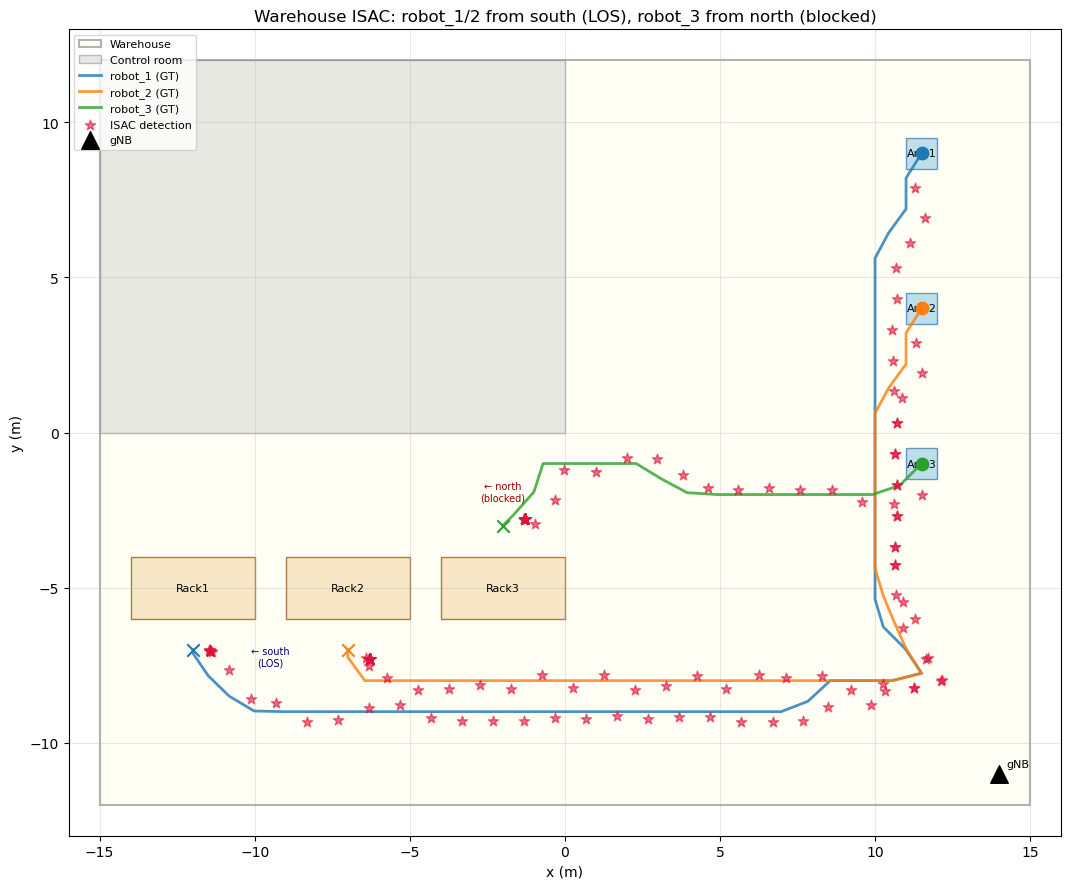

In [15]:
colors = {"robot_1": "tab:blue", "robot_2": "tab:orange", "robot_3": "tab:green"}

fig, ax = plt.subplots(figsize=(12, 9))

ax.add_patch(mpatches.Rectangle((-15, -12), 30, 24, linewidth=1.5,
             edgecolor="black", facecolor="lightyellow", alpha=0.3, label="Warehouse"))
ax.add_patch(mpatches.Rectangle((-15, 0), 15, 12, linewidth=1,
             edgecolor="gray", facecolor="lightgray", alpha=0.5, label="Control room"))

for rx, ry, rlabel in [(-14, -6, "Rack1"), (-9, -6, "Rack2"), (-4, -6, "Rack3")]:
    ax.add_patch(mpatches.Rectangle((rx, -6), 4, 2, linewidth=1,
                 edgecolor="saddlebrown", facecolor="wheat", alpha=0.7))
    ax.text(rx + 2, ry + 1, rlabel, ha="center", va="center", fontsize=8)

for ax_, ay, alabel in [(11, 8.5, "Arm1"), (11, 3.5, "Arm2"), (11, -1.5, "Arm3")]:
    ax.add_patch(mpatches.Rectangle((ax_, ay), 1, 1, linewidth=1,
                 edgecolor="steelblue", facecolor="lightblue", alpha=0.8))
    ax.text(ax_ + 0.5, ay + 0.5, alabel, ha="center", va="center", fontsize=8)

for name, pts in wh_trajectories.items():
    if not pts: continue
    pts = np.array(pts)
    ax.plot(pts[:, 0], pts[:, 1], color=colors[name], linewidth=2, alpha=0.8,
            label=f"{name} (GT)")
    ax.scatter(pts[0, 0], pts[0, 1], color=colors[name], marker="o", s=80, zorder=5)
    ax.scatter(pts[-1, 0], pts[-1, 1], color=colors[name], marker="x", s=80, zorder=5)

det_xy = [p[:2] for frame in wh_detections for p in frame["positions"]]
if det_xy:
    det_xy = np.array(det_xy)
    ax.scatter(det_xy[:, 0], det_xy[:, 1], marker="*", color="crimson",
               s=60, alpha=0.6, label="ISAC detection", zorder=4)

gnb = wh_radio_settings["tx_locations"][0]
ax.scatter(gnb[0], gnb[1], color="black", marker="^", s=160, zorder=6, label="gNB")
ax.annotate("gNB", (gnb[0], gnb[1]), textcoords="offset points", xytext=(5, 5), fontsize=8)

# Annotate approach directions
ax.annotate("← south\n(LOS)", xy=(-9.5, -7.5), fontsize=7, color="navy", ha="center")
ax.annotate("← north\n(blocked)", xy=(-2, -2.2), fontsize=7, color="darkred", ha="center")

ax.set_xlim(-16, 16); ax.set_ylim(-13, 13)
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title("Warehouse ISAC: robot_1/2 from south (LOS), robot_3 from north (blocked)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

In [16]:

MATCH_THRESHOLD_M = 1.0

wh_dr, wh_miss, wh_fp_per_frame, wh_frame_stats = compute_isac_metrics(
    wh_detections, wh_trajectories, robots, rx_update_interval, MATCH_THRESHOLD_M
)

print(f"Match threshold : {MATCH_THRESHOLD_M} m")
print(f"Detection rate  : {wh_dr:.3f}  ({wh_dr * 100:.1f}%)")
print(f"Miss rate       : {wh_miss:.3f}  ({wh_miss * 100:.1f}%)")
print(f"False positives/frame : {wh_fp_per_frame:.3f}")


Match threshold : 1.0 m
Detection rate  : 0.978  (97.8%)
Miss rate       : 0.022  (2.2%)
False positives/frame : 0.017


# ISAC Scalability & Robustness Stress Test

Here, we evaluate the scalability and robustness of the ISAC system across different target densities ranging from 1 to 20 UEs in both Free Space and Warehouse environments. The same trajectories are used for both scenes by fixing the random seed at each UE count.

In [ ]:

import time
import numpy as np
import matplotlib.pyplot as plt
import gc
import tensorflow as tf

num_ues_list = list(range(1, 11))
scenes = ["free_space", "warehouse"]
SCALABILITY_SEEDS = [42, 43, 44]
MAX_SCALABILITY_UES = max(num_ues_list)

results_dr_runs = {s: [] for s in scenes}
results_fp_runs = {s: [] for s in scenes}
results_dr = {s: [] for s in scenes}
results_fpr = {s: [] for s in scenes}  # Backward-compatible name; values are FP/frame.
results_dr_std = {s: [] for s in scenes}
results_fpr_std = {s: [] for s in scenes}

rx_height = 1.5
rx_update_interval = float(radio_settings["rx_update_interval"])


def _make_nested_scalability_scenario(seed, max_ues):
    rng = np.random.default_rng(seed)
    starts = [
        [float(rng.uniform(-11.5, 11.5)), float(rng.uniform(-8.0, 8.0)), rx_height]
        for _ in range(max_ues)
    ]
    waypoints = {
        f"ue_{i}": [
            [float(rng.uniform(-11.5, 11.5)), float(rng.uniform(-8.0, 8.0))]
            for _ in range(5)
        ]
        for i in range(1, max_ues + 1)
    }
    return starts, waypoints


for scene_name in scenes:
    scene_xml = f"{ASSETS}/scenes/{scene_name}/{scene_name}.xml"
    scene_obj = f"{ASSETS}/scenes/{scene_name}/{scene_name}.obj"
    print(f"\n{'='*40}\nEvaluating Scene: {scene_name.upper()}\n{'='*40}")

    scene_dr_runs = []
    scene_fp_runs = []

    for seed in SCALABILITY_SEEDS:
        starts_all, waypoints_all = _make_nested_scalability_scenario(seed, MAX_SCALABILITY_UES)
        seed_dr = []
        seed_fp = []
        print(f"--- Seed {seed} ---")

        for num_ues in num_ues_list:
            print(f"Running simulation for {num_ues} UEs")

            if scene_name == "warehouse":
                scalable_radio_settings = wh_radio_settings.copy()
                scalable_mobility_settings = wh_mobility_settings.copy()
                scalable_radio_settings["rx_speed"] = [_WH_UE_SPEED] * num_ues
            else:
                scalable_radio_settings = radio_settings.copy()
                scalable_mobility_settings = mobility_settings.copy()
                scalable_radio_settings["rx_speed"] = [_UE_SPEED] * num_ues

            scalable_radio_settings["scene"] = scene_xml
            scalable_radio_settings["simulation_duration"] = 15.0
            scalable_radio_settings["rx_locations"] = starts_all[:num_ues]
            scalable_radio_settings["rx_names"] = [f"ue_{i}" for i in range(1, num_ues + 1)]
            scalable_radio_settings["rx_ids"] = list(range(1, num_ues + 1))
            scalable_radio_settings["isac_single_bounce_only"] = True
            scalable_radio_settings["isac_tracker_max_tracks"] = max(10, num_ues)
            if "isac_mti_dist_threshold" in scalable_radio_settings:
                scalable_radio_settings["isac_mti_dist_thresh"] = scalable_radio_settings.pop("isac_mti_dist_threshold")

            scalable_mobility_settings["scene"] = scene_obj
            scalable_mobility_settings["rx_names"] = scalable_radio_settings["rx_names"]
            scalable_mobility_settings["rx_ids"] = scalable_radio_settings["rx_ids"]
            scalable_mobility_settings["rx_modes"] = ["WAYPOINT"] * num_ues
            scalable_mobility_settings["rx_speed"] = scalable_radio_settings["rx_speed"]
            scalable_mobility_settings["rx_locations"] = [[p[0], p[1], 0.0] for p in scalable_radio_settings["rx_locations"]]

            sionnart_scale = SionnaRT()
            sionnart_scale.initialize(scalable_radio_settings)
            # Use a target-free clutter map; never learn MTI background from the first live UE frame.
            sionnart_scale.prime_mti_background(n_frames=1)
            mobility_scale = SionnaMobility()
            mobility_scale.initialize(scalable_mobility_settings)

            ues = scalable_radio_settings["rx_names"]
            SCALABLE_WAYPOINTS = {name: waypoints_all[name] for name in ues}
            wp_idx = {name: 1 for name in ues}
            current_dest = {name: SCALABLE_WAYPOINTS[name][1] for name in ues}
            trajectories_scale = {name: [] for name in ues}

            for name in ues:
                d = current_dest[name]
                mobility_scale.set_destination(name, [d[0], d[1], 0.0])

            num_steps = max(1, int(float(scalable_radio_settings["simulation_duration"]) / rx_update_interval))
            for step in range(num_steps):
                timestamp = step * rx_update_interval
                for name in ues:
                    pos = mobility_scale.update_position(name, timestamp)
                    if pos is not None:
                        sionnart_scale.update_position(name, [pos[0], pos[1], rx_height])
                        trajectories_scale[name].append([pos[0], pos[1], rx_height])
                        dest = current_dest[name]
                        if np.hypot(pos[0] - dest[0], pos[1] - dest[1]) < 1.5:
                            nxt = _advance_wp(name, SCALABLE_WAYPOINTS, wp_idx)
                            mobility_scale.set_destination(name, [nxt[0], nxt[1], 0.0])
                            current_dest[name] = nxt
                sionnart_scale.perform_calculation(timestamp)

            track_detections_scale = sionnart_scale.get_detected_objects()
            raw_detections_scale = sionnart_scale.get_raw_detected_objects()

            dr, miss, _, _ = compute_isac_metrics(
                track_detections_scale, trajectories_scale, ues, rx_update_interval, match_threshold=1.5
            )
            _, _, fp_per_frame, _ = compute_isac_metrics(
                raw_detections_scale, trajectories_scale, ues, rx_update_interval, match_threshold=1.5
            )

            seed_dr.append(dr)
            seed_fp.append(fp_per_frame)
            print(f"DR: {dr:.3f} | FP/frame: {fp_per_frame:.3f}")

            del sionnart_scale
            del mobility_scale
            tf.keras.backend.clear_session()
            gc.collect()

        scene_dr_runs.append(seed_dr)
        scene_fp_runs.append(seed_fp)

    dr_arr = np.asarray(scene_dr_runs, dtype=float)
    fp_arr = np.asarray(scene_fp_runs, dtype=float)
    results_dr_runs[scene_name] = dr_arr
    results_fp_runs[scene_name] = fp_arr
    results_dr[scene_name] = dr_arr.mean(axis=0).tolist()
    results_fpr[scene_name] = fp_arr.mean(axis=0).tolist()
    results_dr_std[scene_name] = dr_arr.std(axis=0, ddof=0).tolist()
    results_fpr_std[scene_name] = fp_arr.std(axis=0, ddof=0).tolist()



Evaluating Scene: FREE_SPACE
--- Seed 42 ---
Running simulation for 1 UEs
[MTI-prime] frame 1/1: 321 clutter ERPs added to background
DR: 0.900 | FP/frame: 0.000
Running simulation for 2 UEs
[MTI-prime] frame 1/1: 542 clutter ERPs added to background
DR: 0.850 | FP/frame: 0.000
Running simulation for 3 UEs
[MTI-prime] frame 1/1: 685 clutter ERPs added to background
DR: 0.787 | FP/frame: 0.100
Running simulation for 4 UEs
[MTI-prime] frame 1/1: 948 clutter ERPs added to background
DR: 0.667 | FP/frame: 0.367
Running simulation for 5 UEs
[MTI-prime] frame 1/1: 1171 clutter ERPs added to background
DR: 0.596 | FP/frame: 0.667
Running simulation for 6 UEs
[MTI-prime] frame 1/1: 1451 clutter ERPs added to background
DR: 0.625 | FP/frame: 0.667
Running simulation for 7 UEs
[MTI-prime] frame 1/1: 1783 clutter ERPs added to background
DR: 0.618 | FP/frame: 0.733
Running simulation for 8 UEs
[MTI-prime] frame 1/1: 2217 clutter ERPs added to background
DR: 0.611 | FP/frame: 0.733
Running simula

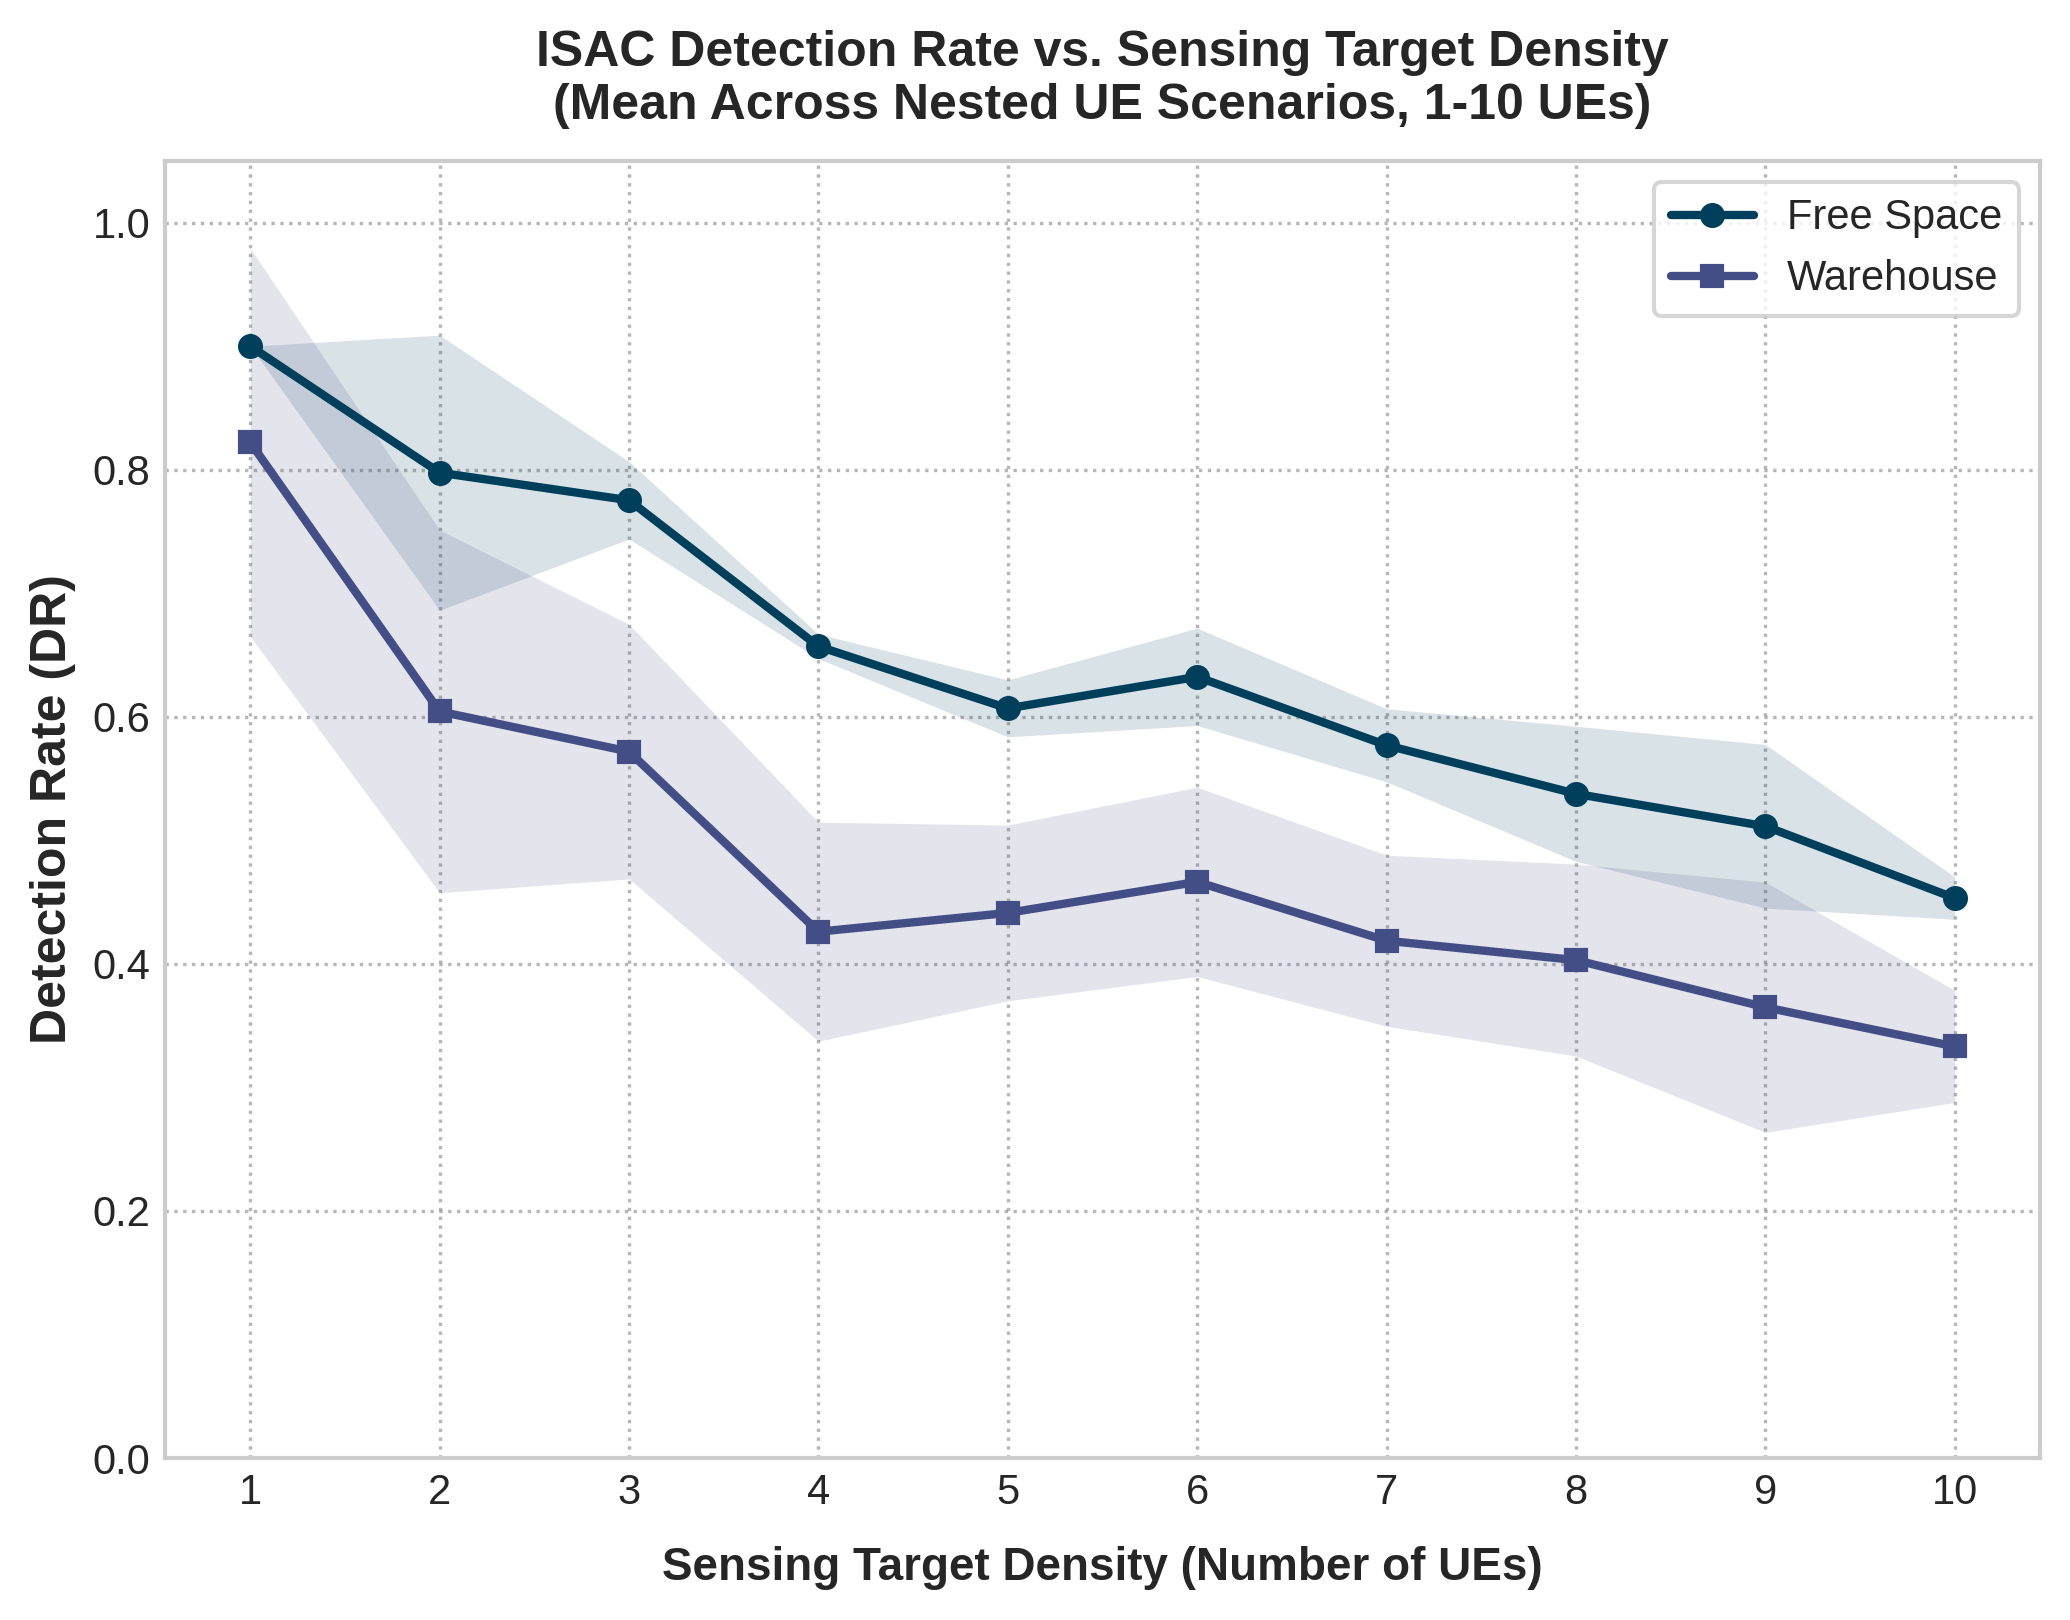

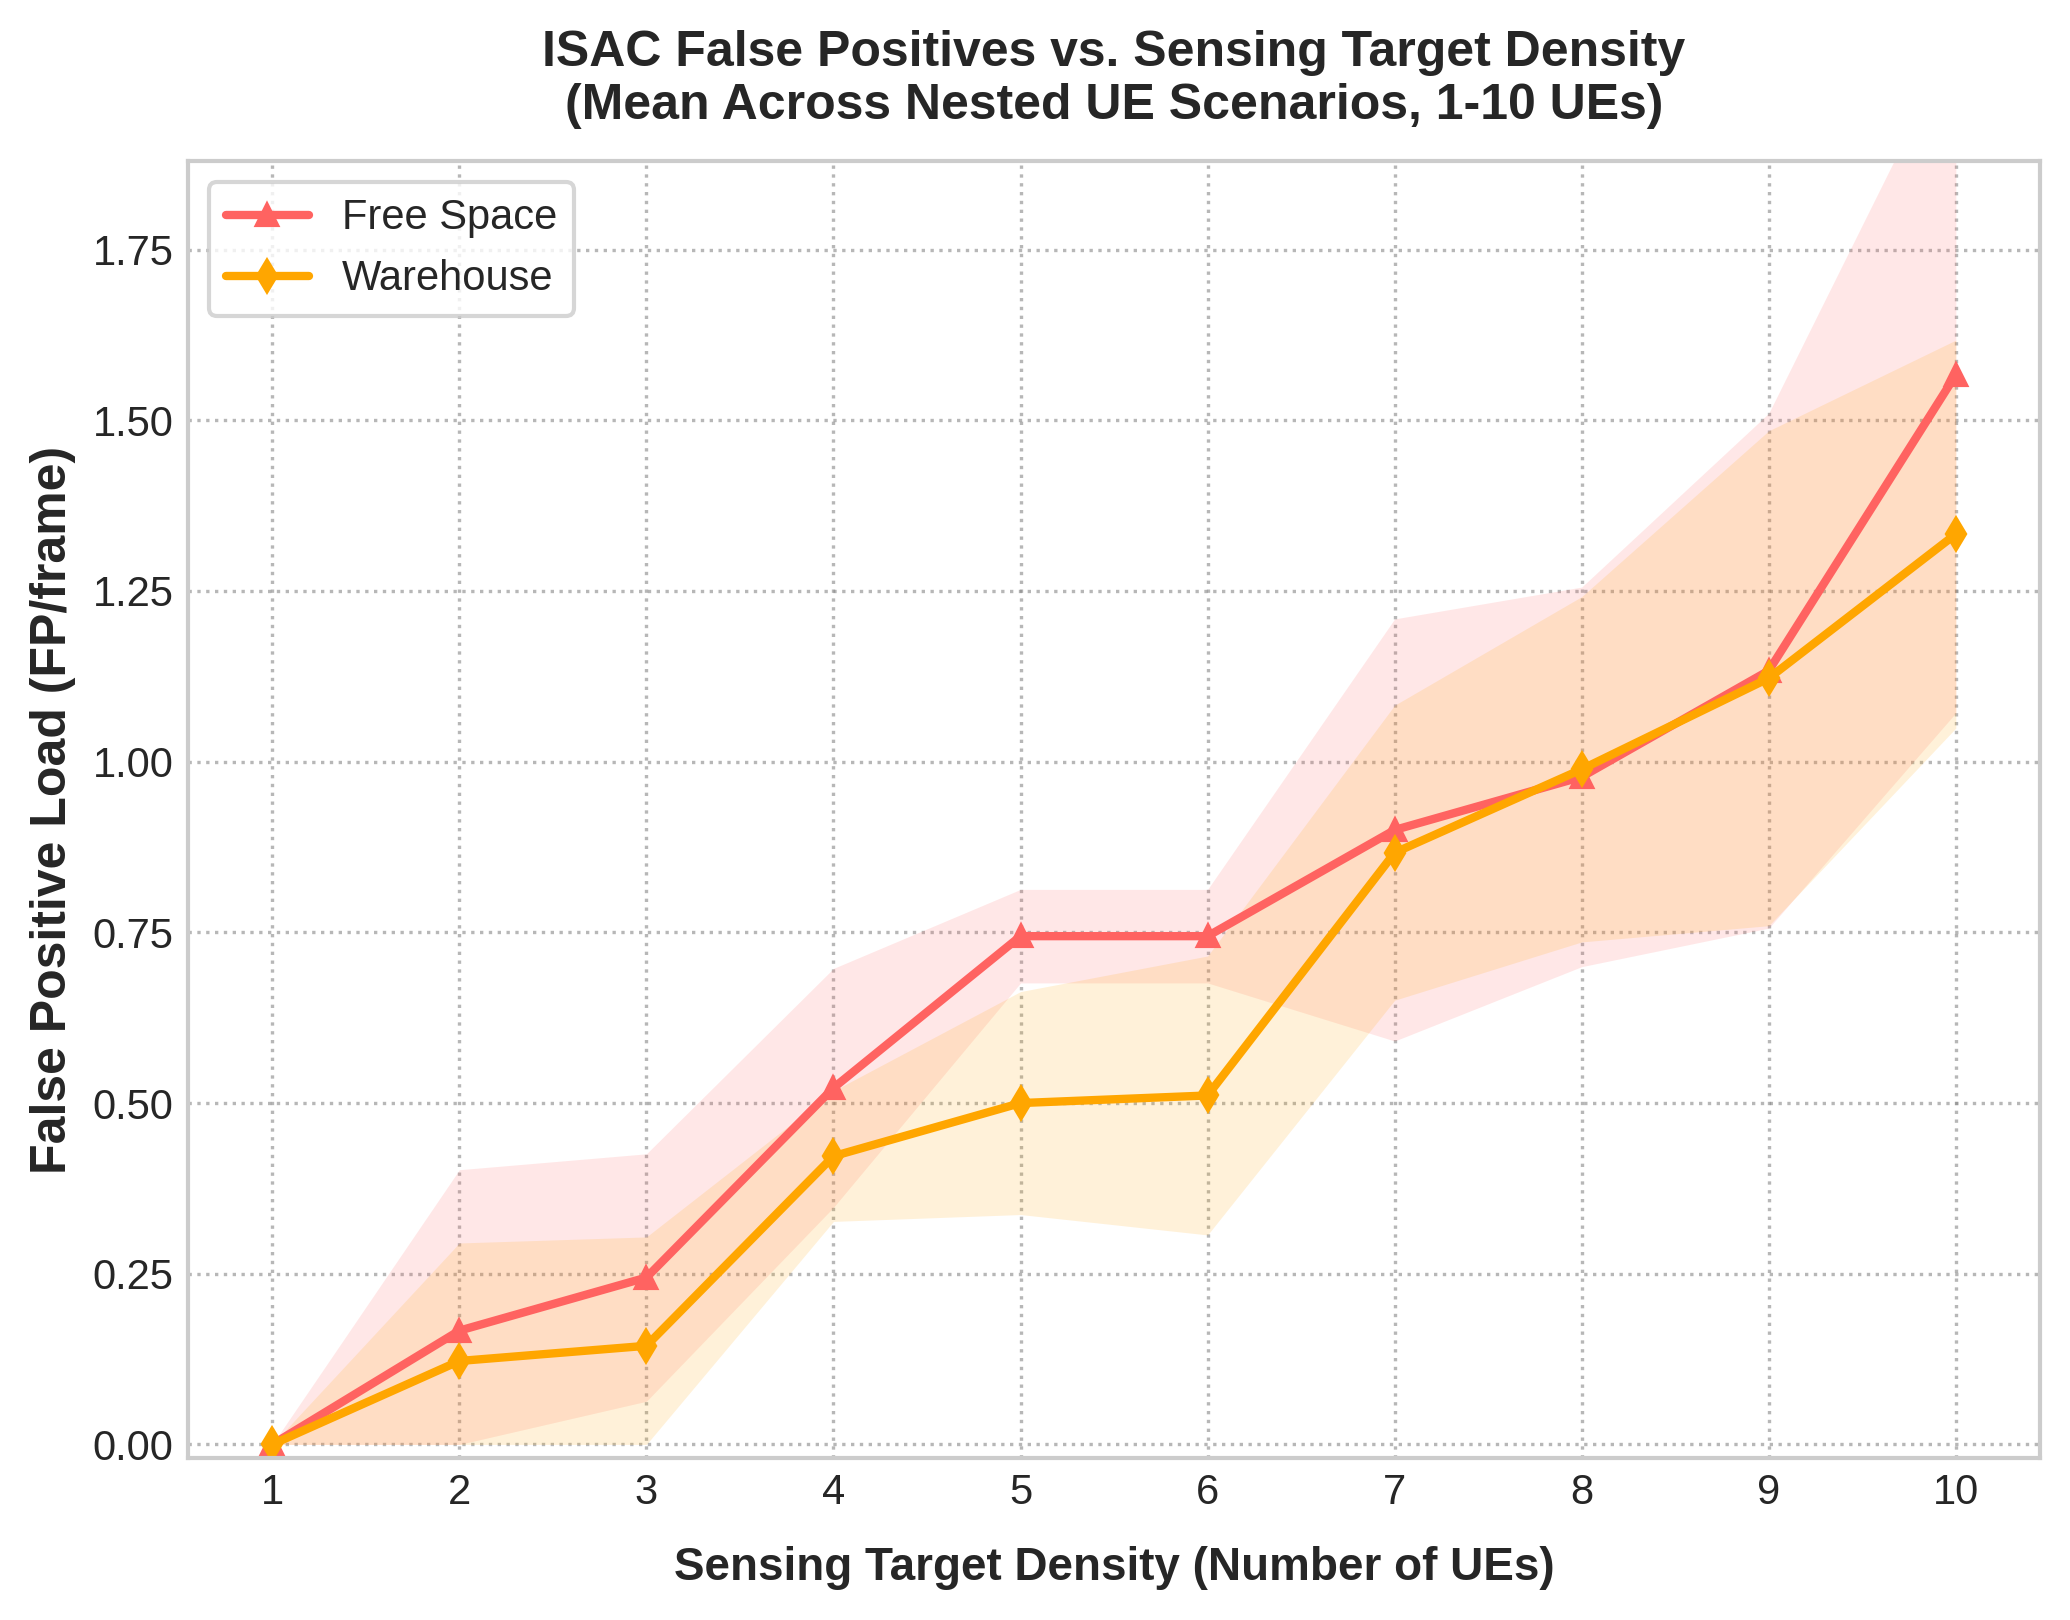

In [ ]:

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

x = np.asarray(num_ues_list)

fig1, ax1 = plt.subplots(figsize=(7, 5.5), dpi=300)
color_dr_fs = '#003f5c'
color_dr_wh = '#444e86'
for scene_name, color, marker, label in [
    ("free_space", color_dr_fs, 'o', "Free Space"),
    ("warehouse", color_dr_wh, 's', "Warehouse"),
]:
    y = np.asarray(results_dr[scene_name])
    yerr = np.asarray(results_dr_std[scene_name])
    ax1.plot(x, y, marker + '-', label=label, color=color, linewidth=2, markersize=5)
    ax1.fill_between(x, np.clip(y - yerr, 0.0, 1.0), np.clip(y + yerr, 0.0, 1.0),
                     color=color, alpha=0.15, linewidth=0)
ax1.set_xlabel("Sensing Target Density (Number of UEs)", fontsize=11, fontweight='bold', labelpad=8)
ax1.set_ylabel("Detection Rate (DR)", fontsize=12, fontweight='bold')
ax1.tick_params(axis='both', labelsize=10)
ax1.set_ylim(0.0, 1.05)
ax1.set_xticks(x)
ax1.set_title("ISAC Detection Rate vs. Sensing Target Density\n(Mean Across Nested UE Scenarios, 1-10 UEs)", fontsize=12, fontweight='bold', pad=10)
ax1.legend(loc='best', frameon=True, facecolor='white', edgecolor='#cccccc', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6, color='#888888')
plt.tight_layout()
plt.savefig("isac_scalability_detection_rate.png", dpi=300, bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 5.5), dpi=300)
color_fp_fs = '#ff6361'
color_fp_wh = '#ffa600'
for scene_name, color, marker, label in [
    ("free_space", color_fp_fs, '^', "Free Space"),
    ("warehouse", color_fp_wh, 'd', "Warehouse"),
]:
    y = np.asarray(results_fpr[scene_name])
    yerr = np.asarray(results_fpr_std[scene_name])
    ax2.plot(x, y, marker + '-', label=label, color=color, linewidth=2, markersize=5)
    ax2.fill_between(x, np.clip(y - yerr, 0.0, None), y + yerr,
                     color=color, alpha=0.15, linewidth=0)
ax2.set_xlabel("Sensing Target Density (Number of UEs)", fontsize=11, fontweight='bold', labelpad=8)
ax2.set_ylabel("False Positive Load (FP/frame)", fontsize=12, fontweight='bold')
ax2.tick_params(axis='both', labelsize=10)
ax2.set_xticks(x)
max_fp = max(max(results_fpr['free_space']), max(results_fpr['warehouse']))
ax2.set_ylim(-0.02, max(max_fp * 1.2, 0.1) if max_fp else 1.0)
ax2.set_title("ISAC False Positives vs. Sensing Target Density\n(Mean Across Nested UE Scenarios, 1-10 UEs)", fontsize=12, fontweight='bold', pad=10)
ax2.legend(loc='best', frameon=True, facecolor='white', edgecolor='#cccccc', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6, color='#888888')
plt.tight_layout()
plt.savefig("isac_scalability_false_positive_rate.png", dpi=300, bbox_inches='tight')
plt.show()


# ISAC UE Speed Sensitivity Test

This section evaluates ISAC detection performance as UE speed varies from 0.5 m/s to 5.0 m/s while keeping UE density fixed.


In [17]:

import time
import numpy as np
import matplotlib.pyplot as plt
import gc
import tensorflow as tf

try:
    import torch
except Exception:
    torch = None

try:
    import drjit as _drjit
except Exception:
    _drjit = None

speed_list = np.arange(0.5, 5.0 + 0.5, 0.5).round(2).tolist()
SPEED_SWEEP_NUM_UES = 5
SPEED_SWEEP_SEEDS = [42, 43, 44]
SPEED_SWEEP_SAMPLES_PER_SRC = 500_000
SPEED_SWEEP_DIFFUSE_REFLECTION = True
SPEED_SWEEP_MAX_DEPTH = 1
scenes = ["free_space", "warehouse"]

speed_results_dr_runs = {s: [] for s in scenes}
speed_results_fp_runs = {s: [] for s in scenes}
speed_results_dr = {s: [] for s in scenes}
speed_results_fpr = {s: [] for s in scenes}  # Backward-compatible name; values are FP/frame.
speed_results_dr_std = {s: [] for s in scenes}
speed_results_fpr_std = {s: [] for s in scenes}

rx_height = 1.5
rx_update_interval = float(radio_settings["rx_update_interval"])


def _release_rt_memory(*objs):
    for obj in objs:
        try:
            if hasattr(obj, "scene"):
                obj.scene = None
            if hasattr(obj, "path_solver"):
                obj.path_solver = None
        except Exception:
            pass
    tf.keras.backend.clear_session()
    if torch is not None:
        try:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                torch.cuda.ipc_collect()
        except Exception:
            pass
    if _drjit is not None:
        try:
            _drjit.sync_thread()
        except Exception:
            pass
        try:
            _drjit.flush_malloc_cache()
        except Exception:
            pass
    gc.collect()


def _make_speed_sweep_scenario(seed, num_ues):
    rng = np.random.default_rng(seed)
    starts = [
        [float(rng.uniform(-11.5, 11.5)), float(rng.uniform(-8.0, 8.0)), rx_height]
        for _ in range(num_ues)
    ]
    waypoints = {
        f"ue_{i}": [
            [float(rng.uniform(-11.5, 11.5)), float(rng.uniform(-8.0, 8.0))]
            for _ in range(6)
        ]
        for i in range(1, num_ues + 1)
    }
    return starts, waypoints


for scene_name in scenes:
    scene_xml = f"{ASSETS}/scenes/{scene_name}/{scene_name}.xml"
    scene_obj = f"{ASSETS}/scenes/{scene_name}/{scene_name}.obj"
    print(f"\n{'='*40}\nSpeed Sweep Scene: {scene_name.upper()}\n{'='*40}")

    scene_dr_runs = []
    scene_fp_runs = []

    for seed in SPEED_SWEEP_SEEDS:
        starts, waypoints = _make_speed_sweep_scenario(seed, SPEED_SWEEP_NUM_UES)
        seed_dr = []
        seed_fp = []
        print(f"--- Seed {seed} ---")

        for ue_speed in speed_list:
            print(f"Running simulation for speed={ue_speed:.1f} m/s")
            sionnart_speed = None
            mobility_speed = None
            track_detections_speed = []
            raw_detections_speed = []
            trajectories_speed = {}
            ues_speed = []

            try:
                if scene_name == "warehouse":
                    speed_radio_settings = wh_radio_settings.copy()
                    speed_mobility_settings = wh_mobility_settings.copy()
                else:
                    speed_radio_settings = radio_settings.copy()
                    speed_mobility_settings = mobility_settings.copy()

                speed_radio_settings["scene"] = scene_xml
                speed_radio_settings["simulation_duration"] = 15.0
                speed_radio_settings["rx_locations"] = starts
                speed_radio_settings["rx_names"] = [f"ue_{i}" for i in range(1, SPEED_SWEEP_NUM_UES + 1)]
                speed_radio_settings["rx_ids"] = list(range(1, SPEED_SWEEP_NUM_UES + 1))
                speed_radio_settings["rx_speed"] = [float(ue_speed)] * SPEED_SWEEP_NUM_UES
                speed_radio_settings["isac_samples_per_src"] = SPEED_SWEEP_SAMPLES_PER_SRC
                speed_radio_settings["isac_max_depth"] = SPEED_SWEEP_MAX_DEPTH
                # Target mesh echoes are diffuse-scattering paths; disabling this makes raw detections empty.
                speed_radio_settings["isac_diffuse_reflection"] = SPEED_SWEEP_DIFFUSE_REFLECTION
                speed_radio_settings["isac_single_bounce_only"] = True
                speed_radio_settings["isac_tracker_max_tracks"] = max(10, SPEED_SWEEP_NUM_UES)
                speed_radio_settings["isac_mti_dist_thresh"] = max(
                    0.01, (float(ue_speed) * rx_update_interval / 2.0) - 0.1
                )
                speed_radio_settings.pop("isac_mti_dist_threshold", None)

                speed_mobility_settings["scene"] = scene_obj
                speed_mobility_settings["rx_locations"] = [[p[0], p[1], 0.0] for p in starts]
                speed_mobility_settings["rx_names"] = speed_radio_settings["rx_names"]
                speed_mobility_settings["rx_ids"] = speed_radio_settings["rx_ids"]
                speed_mobility_settings["rx_modes"] = ["WAYPOINT"] * SPEED_SWEEP_NUM_UES
                speed_mobility_settings["rx_speed"] = speed_radio_settings["rx_speed"]

                _release_rt_memory()
                sionnart_speed = SionnaRT()
                sionnart_speed.initialize(speed_radio_settings)
                # Use a target-free clutter map; never learn MTI background from the first live UE frame.
                sionnart_speed.prime_mti_background(n_frames=1)
                mobility_speed = SionnaMobility()
                mobility_speed.initialize(speed_mobility_settings)

                ues_speed = speed_radio_settings["rx_names"]
                wp_idx = {name: 1 for name in ues_speed}
                current_dest = {name: waypoints[name][1] for name in ues_speed}
                trajectories_speed = {name: [] for name in ues_speed}

                for name in ues_speed:
                    d = current_dest[name]
                    mobility_speed.set_destination(name, [d[0], d[1], 0.0])

                num_steps = max(1, int(float(speed_radio_settings["simulation_duration"]) / rx_update_interval))
                for step in range(num_steps):
                    timestamp = step * rx_update_interval
                    for name in ues_speed:
                        pos = mobility_speed.update_position(name, timestamp)
                        if pos is not None:
                            sionnart_speed.update_position(name, [pos[0], pos[1], rx_height])
                            trajectories_speed[name].append([pos[0], pos[1], rx_height])
                            dest = current_dest[name]
                            if np.hypot(pos[0] - dest[0], pos[1] - dest[1]) < 1.5:
                                nxt = _advance_wp(name, waypoints, wp_idx)
                                mobility_speed.set_destination(name, [nxt[0], nxt[1], 0.0])
                                current_dest[name] = nxt
                    sionnart_speed.perform_calculation(timestamp)

                track_detections_speed = sionnart_speed.get_detected_objects()
                raw_detections_speed = sionnart_speed.get_raw_detected_objects()

                dr, miss, _, _ = compute_isac_metrics(
                    track_detections_speed, trajectories_speed, ues_speed,
                    rx_update_interval, match_threshold=1.5
                )
                _, _, fp_per_frame, _ = compute_isac_metrics(
                    raw_detections_speed, trajectories_speed, ues_speed,
                    rx_update_interval, match_threshold=1.5
                )

                seed_dr.append(dr)
                seed_fp.append(fp_per_frame)
                raw_frames = sum(1 for d in raw_detections_speed if d["positions"])
                track_frames = sum(1 for d in track_detections_speed if d["positions"])
                print(
                    f"DR: {dr:.3f} | FP/frame: {fp_per_frame:.3f} | "
                    f"raw frames: {raw_frames}/{len(raw_detections_speed)} | "
                    f"track frames: {track_frames}/{len(track_detections_speed)}"
                )

            finally:
                del track_detections_speed
                del raw_detections_speed
                del trajectories_speed
                del ues_speed
                if mobility_speed is not None:
                    del mobility_speed
                if sionnart_speed is not None:
                    del sionnart_speed
                _release_rt_memory()

        scene_dr_runs.append(seed_dr)
        scene_fp_runs.append(seed_fp)

    dr_arr = np.asarray(scene_dr_runs, dtype=float)
    fp_arr = np.asarray(scene_fp_runs, dtype=float)
    speed_results_dr_runs[scene_name] = dr_arr
    speed_results_fp_runs[scene_name] = fp_arr
    speed_results_dr[scene_name] = dr_arr.mean(axis=0).tolist()
    speed_results_fpr[scene_name] = fp_arr.mean(axis=0).tolist()
    speed_results_dr_std[scene_name] = dr_arr.std(axis=0, ddof=0).tolist()
    speed_results_fpr_std[scene_name] = fp_arr.std(axis=0, ddof=0).tolist()



Speed Sweep Scene: FREE_SPACE
--- Seed 42 ---
Running simulation for speed=0.5 m/s
[MTI-prime] frame 1/1: 233 clutter ERPs added to background
DR: 0.685 | FP/frame: 0.133 | raw frames: 29/30 | track frames: 27/30
Running simulation for speed=1.0 m/s
[MTI-prime] frame 1/1: 233 clutter ERPs added to background
DR: 0.680 | FP/frame: 0.033 | raw frames: 29/30 | track frames: 27/30
Running simulation for speed=1.5 m/s
[MTI-prime] frame 1/1: 233 clutter ERPs added to background
DR: 0.688 | FP/frame: 0.367 | raw frames: 29/30 | track frames: 27/30
Running simulation for speed=2.0 m/s
[MTI-prime] frame 1/1: 233 clutter ERPs added to background
DR: 0.545 | FP/frame: 0.700 | raw frames: 29/30 | track frames: 27/30
Running simulation for speed=2.5 m/s
[MTI-prime] frame 1/1: 233 clutter ERPs added to background
DR: 0.521 | FP/frame: 1.000 | raw frames: 29/30 | track frames: 27/30
Running simulation for speed=3.0 m/s
[MTI-prime] frame 1/1: 233 clutter ERPs added to background
DR: 0.716 | FP/frame:

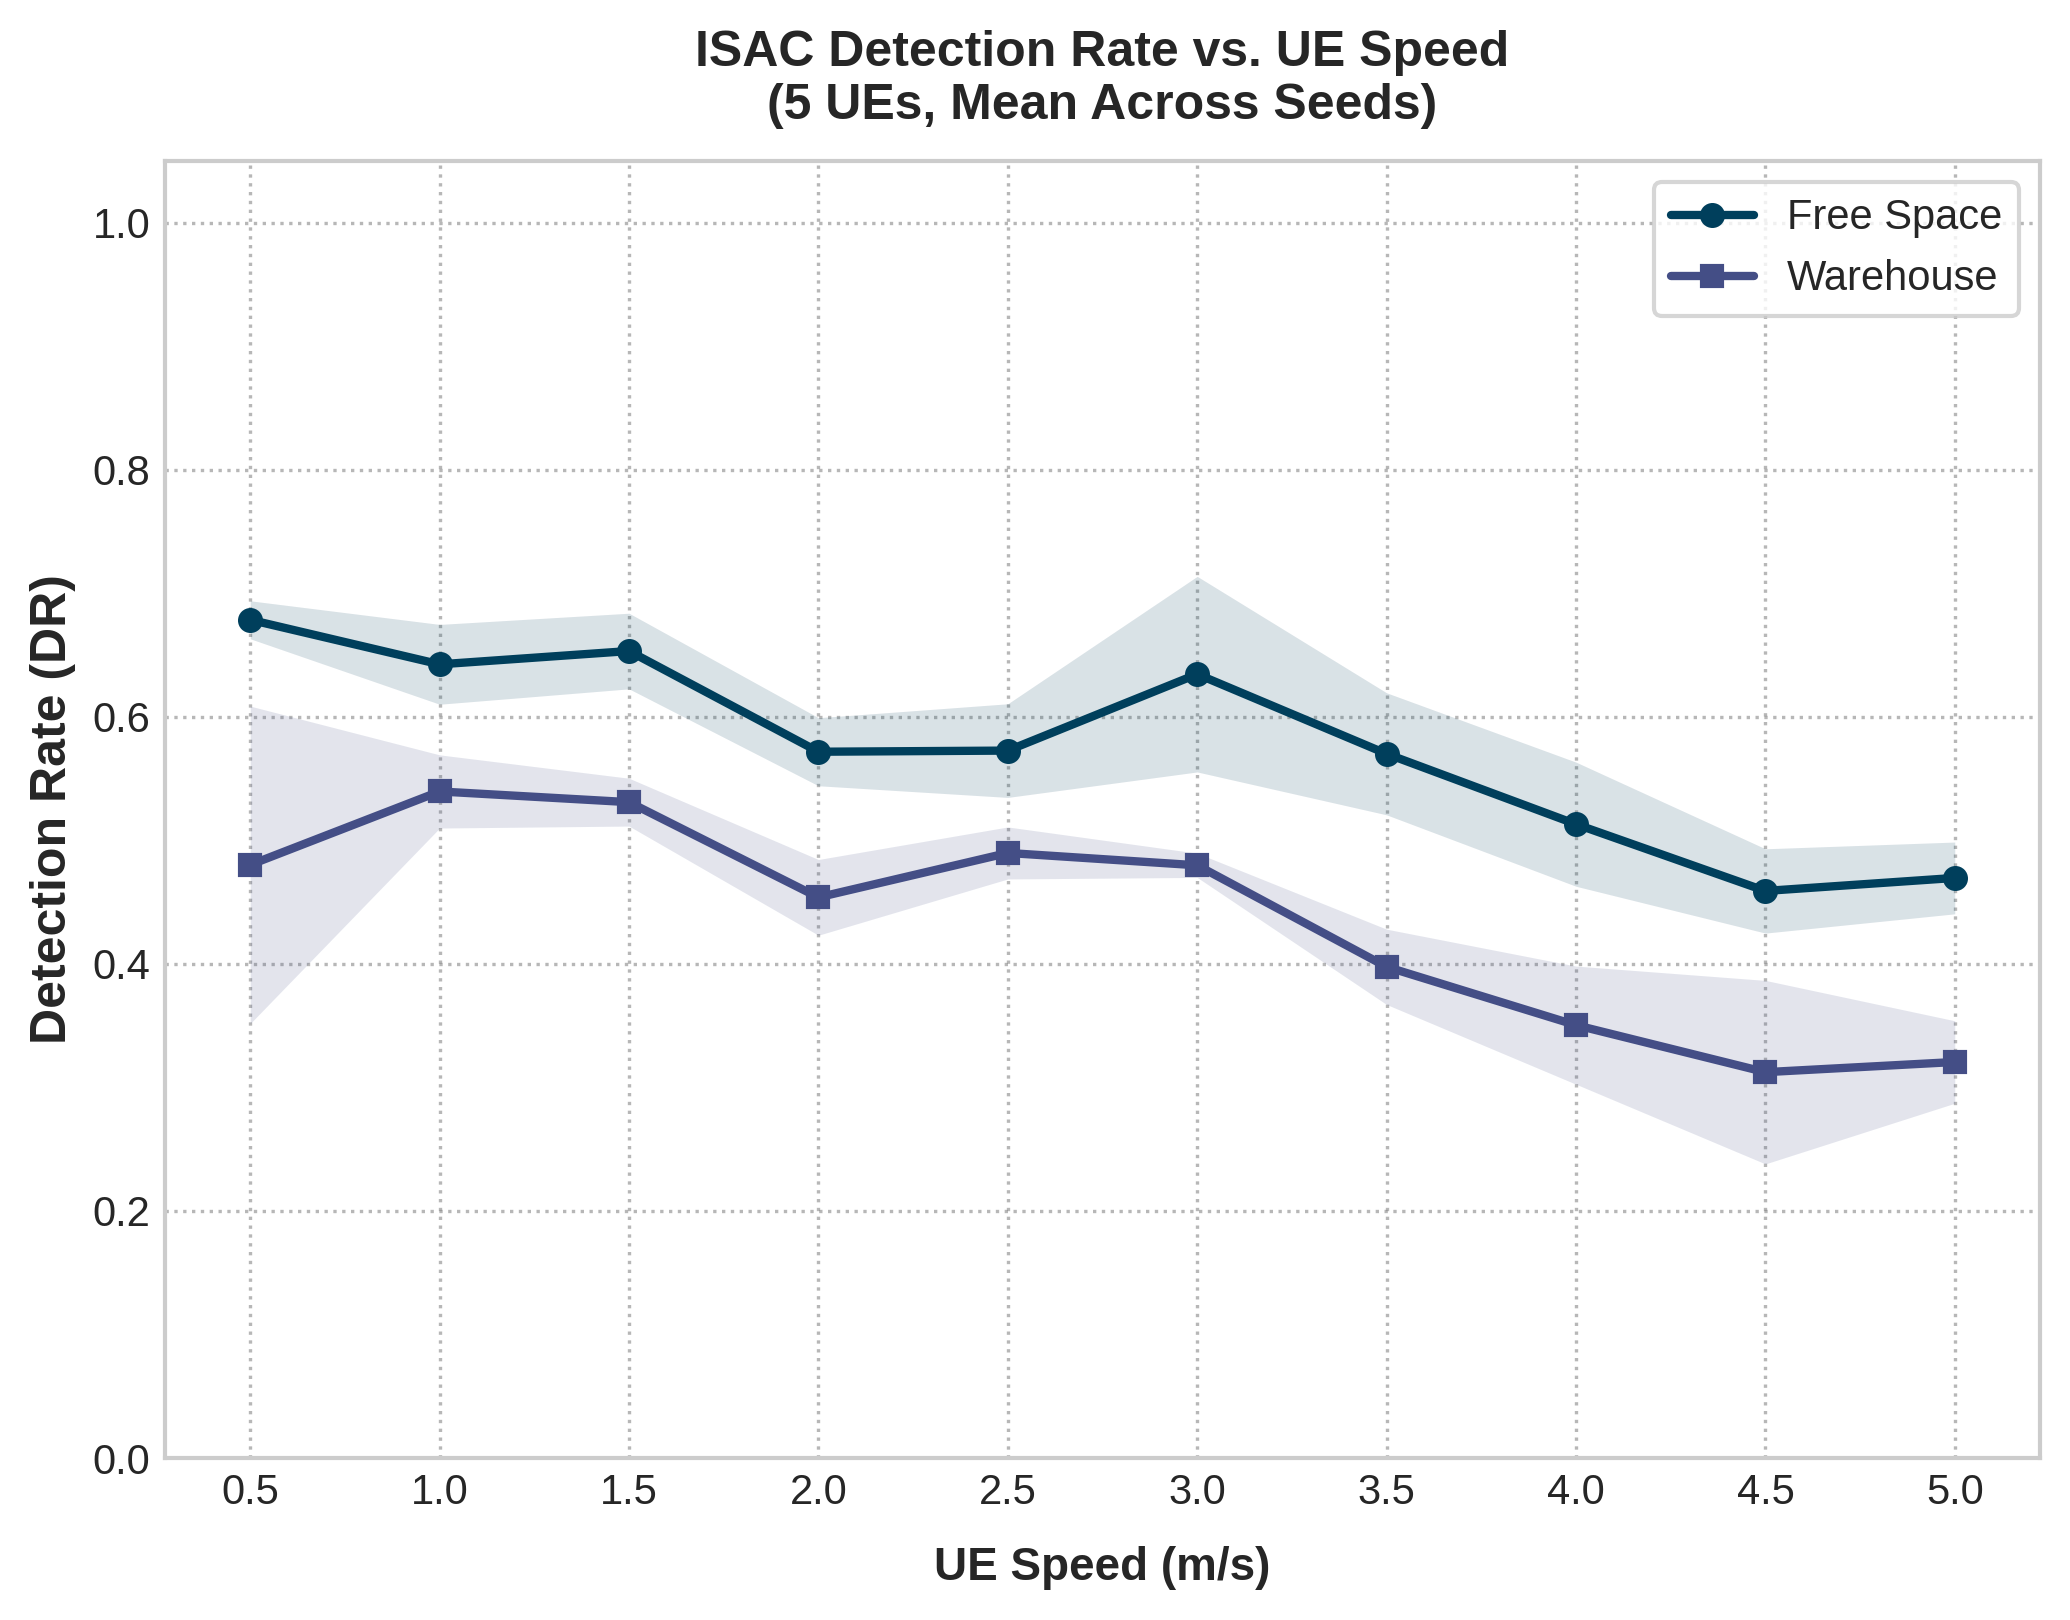

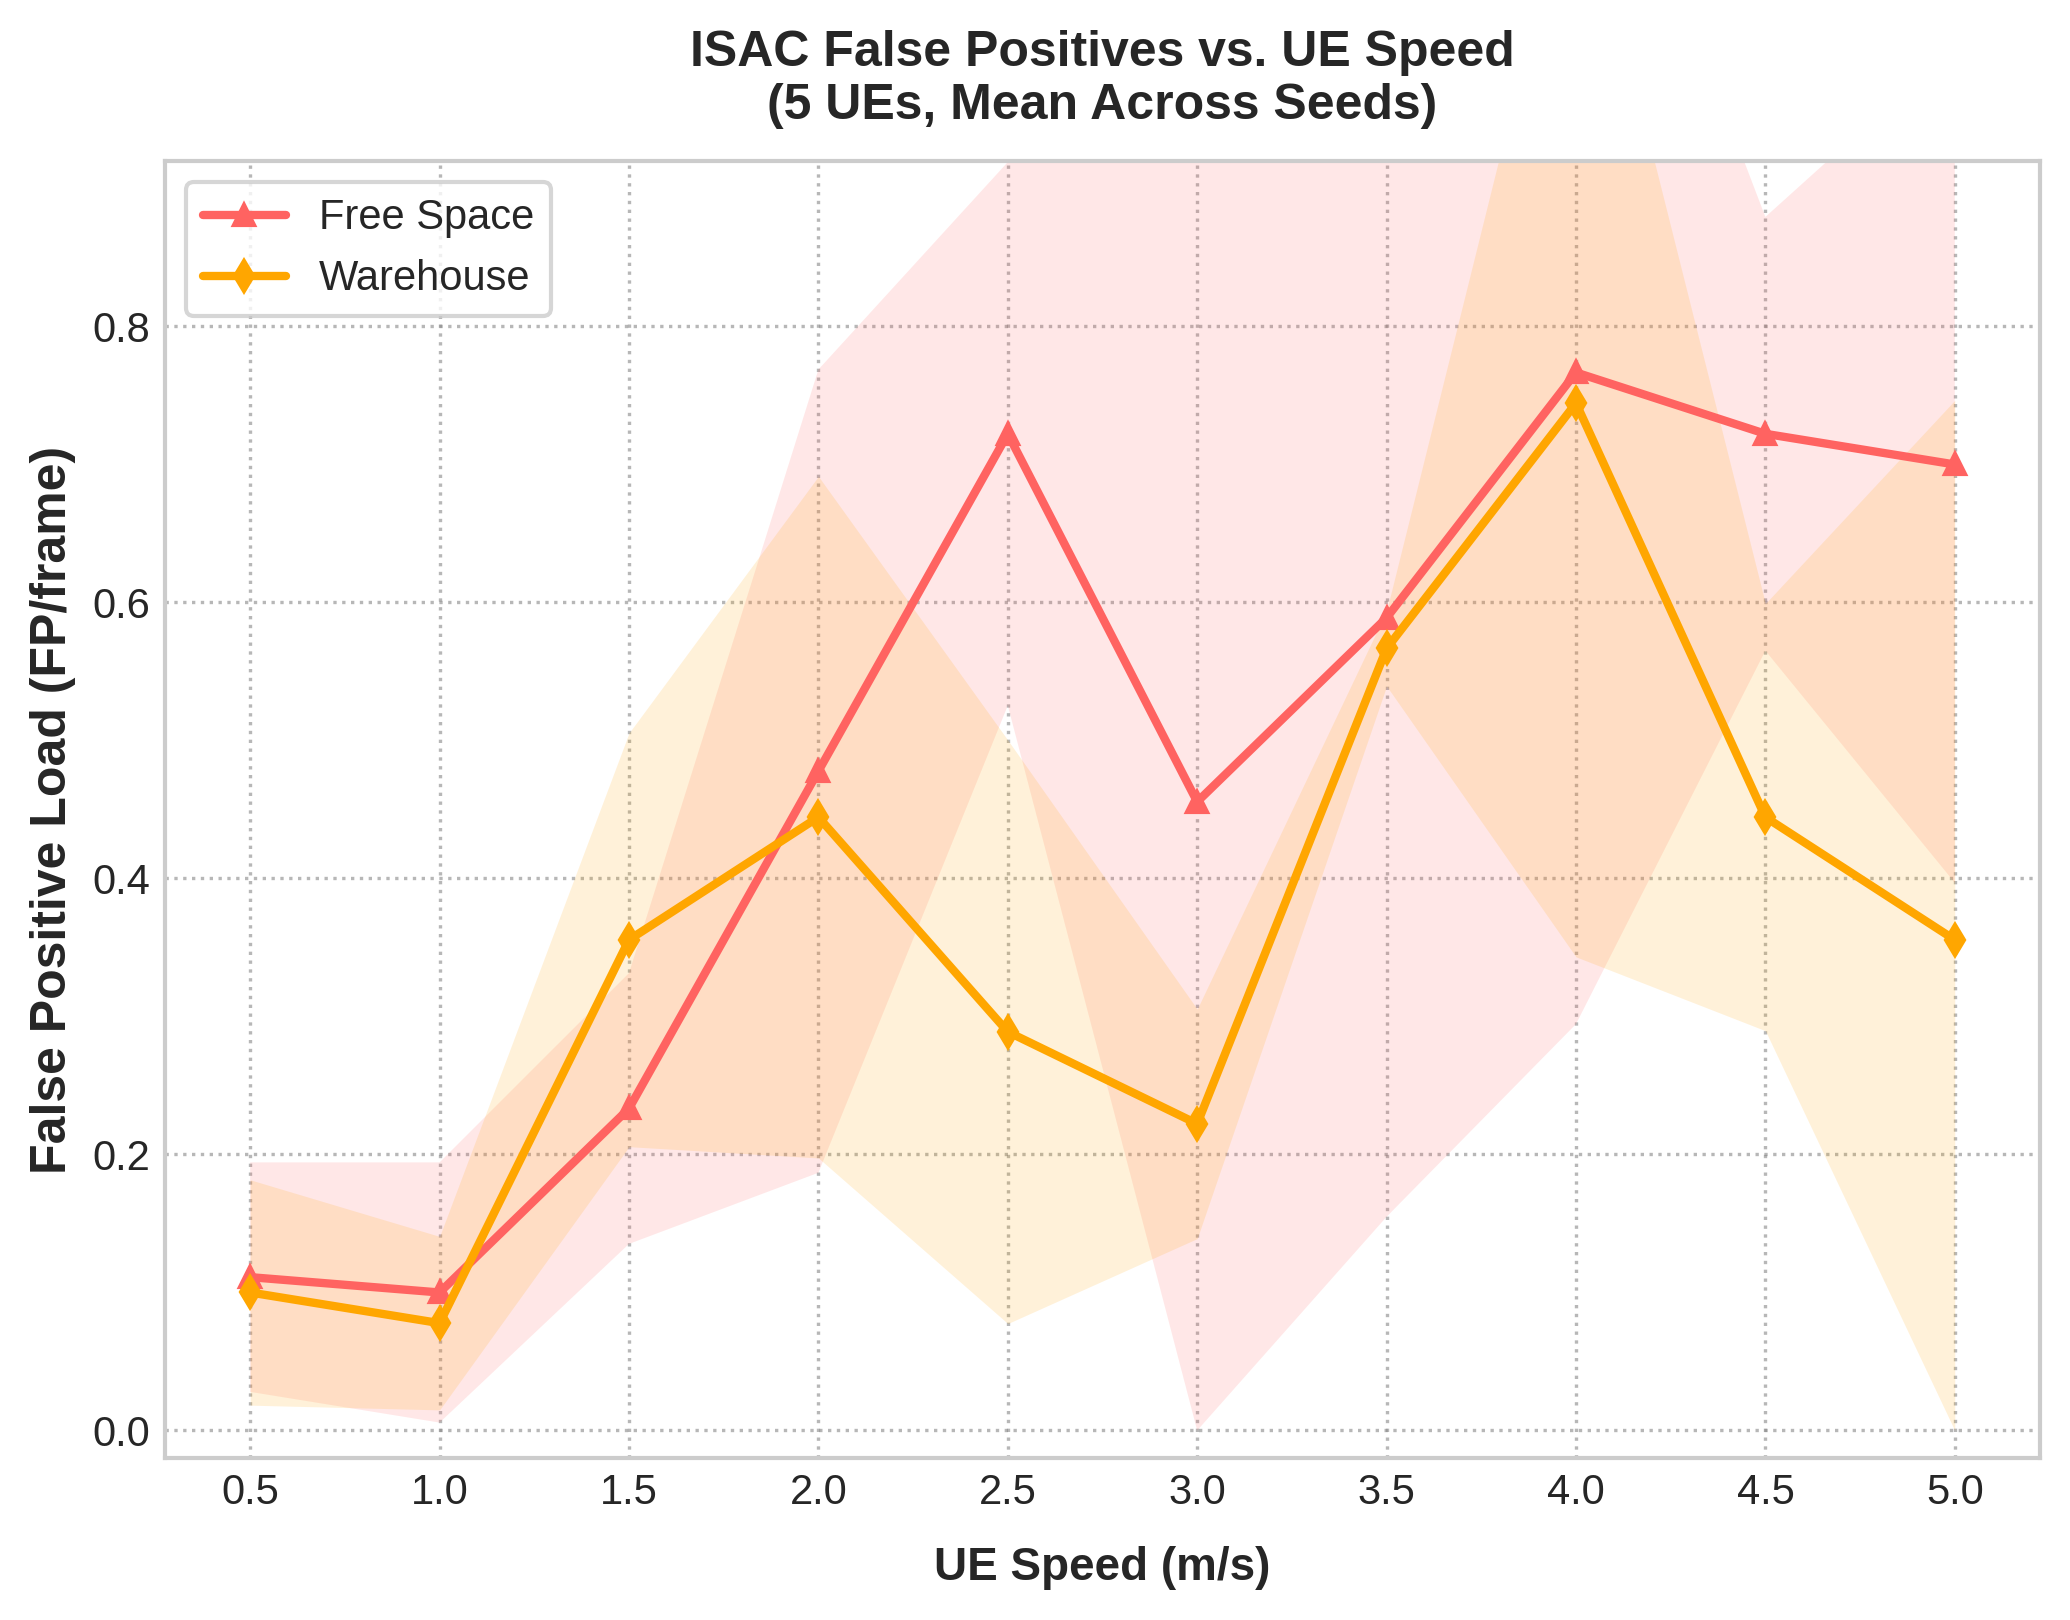

In [18]:

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

x = np.asarray(speed_list)

fig1, ax1 = plt.subplots(figsize=(7, 5.5), dpi=300)
color_dr_fs = '#003f5c'
color_dr_wh = '#444e86'
for scene_name, color, marker, label in [
    ("free_space", color_dr_fs, 'o', "Free Space"),
    ("warehouse", color_dr_wh, 's', "Warehouse"),
]:
    y = np.asarray(speed_results_dr[scene_name])
    yerr = np.asarray(speed_results_dr_std[scene_name])
    ax1.plot(x, y, marker + '-', label=label, color=color, linewidth=2, markersize=5)
    ax1.fill_between(x, np.clip(y - yerr, 0.0, 1.0), np.clip(y + yerr, 0.0, 1.0),
                     color=color, alpha=0.15, linewidth=0)
ax1.set_xlabel("UE Speed (m/s)", fontsize=11, fontweight='bold', labelpad=8)
ax1.set_ylabel("Detection Rate (DR)", fontsize=12, fontweight='bold')
ax1.tick_params(axis='both', labelsize=10)
ax1.set_ylim(0.0, 1.05)
ax1.set_xticks(x)
ax1.set_title("ISAC Detection Rate vs. UE Speed\n(5 UEs, Mean Across Seeds)", fontsize=12, fontweight='bold', pad=10)
ax1.legend(loc='best', frameon=True, facecolor='white', edgecolor='#cccccc', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6, color='#888888')
plt.tight_layout()
plt.savefig("isac_speed_detection_rate.png", dpi=300, bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 5.5), dpi=300)
color_fp_fs = '#ff6361'
color_fp_wh = '#ffa600'
for scene_name, color, marker, label in [
    ("free_space", color_fp_fs, '^', "Free Space"),
    ("warehouse", color_fp_wh, 'd', "Warehouse"),
]:
    y = np.asarray(speed_results_fpr[scene_name])
    yerr = np.asarray(speed_results_fpr_std[scene_name])
    ax2.plot(x, y, marker + '-', label=label, color=color, linewidth=2, markersize=5)
    ax2.fill_between(x, np.clip(y - yerr, 0.0, None), y + yerr,
                     color=color, alpha=0.15, linewidth=0)
ax2.set_xlabel("UE Speed (m/s)", fontsize=11, fontweight='bold', labelpad=8)
ax2.set_ylabel("False Positive Load (FP/frame)", fontsize=12, fontweight='bold')
ax2.tick_params(axis='both', labelsize=10)
ax2.set_xticks(x)
max_fp = max(max(speed_results_fpr['free_space']), max(speed_results_fpr['warehouse']))
ax2.set_ylim(-0.02, max(max_fp * 1.2, 0.1) if max_fp else 1.0)
ax2.set_title("ISAC False Positives vs. UE Speed\n(5 UEs, Mean Across Seeds)", fontsize=12, fontweight='bold', pad=10)
ax2.legend(loc='best', frameon=True, facecolor='white', edgecolor='#cccccc', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6, color='#888888')
plt.tight_layout()
plt.savefig("isac_speed_false_positive_load.png", dpi=300, bbox_inches='tight')
plt.show()


# Baseline Comparison

This section uses a strict paired comparison with the same scene, seed, mobility trace, path-solver settings, and evaluation window for each method. The compared methods are: full ISAC sensing pipeline with MTI and tracker, raw detection with MTI and no tracker, and raw detection without MTI or tracker. Detection rate alone is not used to decide the winner because raw detectors can raise DR by emitting more unconfirmed detections. The tracker is evaluated after warm-up and may bridge short raw-detection gaps with predicted confirmed tracks. Warehouse is the MTI stress case because static scene geometry is enabled as clutter during normal sensing; free-space is kept as a low-clutter sanity check where MTI is not expected to add much.


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import gc
import tensorflow as tf

try:
    import torch
except Exception:
    torch = None

try:
    import drjit as _drjit
except Exception:
    _drjit = None

BASELINE_NUM_UES = 5
BASELINE_SEEDS = [42, 43, 44]
BASELINE_SCENES = ["free_space", "warehouse"]
BASELINE_SAMPLES_PER_SRC = 500_000
BASELINE_MAX_DEPTH = 1
BASELINE_SPEED_MPS = 2.0
BASELINE_SIM_DURATION = 15.0
BASELINE_MATCH_THRESHOLD_M = 1.5
BASELINE_EVAL_START_S = 2.0

baseline_variants = [
    ("Full pipeline (MTI + tracker)", True, "tracker"),
    ("Raw detection + MTI", True, "raw"),
    ("Raw detection only", False, "raw"),
]
baseline_variant_names = [name for name, _, _ in baseline_variants]

baseline_results = {
    scene: {
        variant: {"dr": [], "precision": [], "fpr": [], "f1": [], "fp_per_frame": [], "detections_per_frame": []}
        for variant in baseline_variant_names
    }
    for scene in BASELINE_SCENES
}

rx_height = 1.5
rx_update_interval = float(radio_settings["rx_update_interval"])


def _baseline_cleanup(*objs):
    for obj in objs:
        try:
            if hasattr(obj, "scene"):
                obj.scene = None
            if hasattr(obj, "path_solver"):
                obj.path_solver = None
        except Exception:
            pass
    tf.keras.backend.clear_session()
    if torch is not None:
        try:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                torch.cuda.ipc_collect()
        except Exception:
            pass
    if _drjit is not None:
        try:
            _drjit.sync_thread()
        except Exception:
            pass
        try:
            _drjit.flush_malloc_cache()
        except Exception:
            pass
    gc.collect()


def _make_baseline_scenario(seed, num_ues):
    rng = np.random.default_rng(seed)
    starts = [
        [float(rng.uniform(-11.5, 11.5)), float(rng.uniform(-8.0, 8.0)), rx_height]
        for _ in range(num_ues)
    ]
    waypoints = {
        f"ue_{i}": [
            [float(rng.uniform(-11.5, 11.5)), float(rng.uniform(-8.0, 8.0))]
            for _ in range(5)
        ]
        for i in range(1, num_ues + 1)
    }
    return starts, waypoints


def _match_detections_to_gt(dets, gt, match_threshold):
    """One-to-one thresholded Hungarian matching for detection metrics."""
    dets = np.asarray(dets, dtype=float) if len(dets) else np.empty((0, 3))
    gt = np.asarray(gt, dtype=float) if len(gt) else np.empty((0, 3))
    n_det, n_gt = len(dets), len(gt)
    if n_det == 0 or n_gt == 0:
        return 0, n_det, n_gt, []

    from scipy.optimize import linear_sum_assignment

    dist = np.linalg.norm(dets[:, None, :] - gt[None, :, :], axis=-1)
    rows, cols = linear_sum_assignment(dist)
    pairs = [(int(i), int(j), float(dist[i, j])) for i, j in zip(rows, cols) if dist[i, j] <= match_threshold]
    tp = len(pairs)
    fp = n_det - tp
    fn = n_gt - tp
    return tp, fp, fn, pairs


def _filter_frames_after(detections, start_time_s):
    return [frame for frame in detections if frame["time"] >= start_time_s]


def _gt_frames_after(gt_frames, start_time_s):
    return [frame for frame in gt_frames if frame["time"] >= start_time_s]


def compute_isac_confusion_metrics(detections, gt_frames, match_threshold=1.5, start_time_s=0.0):
    """Return recall/DR, precision, F1, FP ratio, and FP/frame against per-frame GT."""
    eval_detections = _filter_frames_after(detections, start_time_s)
    eval_gt = _gt_frames_after(gt_frames, start_time_s)
    det_by_time = {round(frame["time"], 9): frame for frame in eval_detections}
    gt_by_time = {round(frame["time"], 9): frame["positions"] for frame in eval_gt}
    eval_times = sorted(set(gt_by_time) | set(det_by_time))

    total_gt = total_tp = total_fp = total_fn = total_dets = 0
    frame_debug = []

    for t_key in eval_times:
        frame = det_by_time.get(t_key)
        gt = gt_by_time.get(t_key, [])
        dets = frame["positions"] if frame and frame["positions"] else []
        tp, fp, fn, pairs = _match_detections_to_gt(dets, gt, match_threshold)

        total_gt += len(gt)
        total_dets += len(dets)
        total_tp += tp
        total_fp += fp
        total_fn += fn
        frame_debug.append({
            "time": frame["time"] if frame else float(t_key),
            "gt": len(gt),
            "detections": len(dets),
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "matches": pairs,
        })

    dr = total_tp / total_gt if total_gt else 0.0
    precision = total_tp / total_dets if total_dets else 0.0
    false_positive_rate = total_fp / total_dets if total_dets else 0.0
    miss_rate = total_fn / total_gt if total_gt else 0.0
    f1 = 2.0 * dr * precision / (dr + precision) if (dr + precision) else 0.0
    eval_frame_count = len(eval_times)
    fp_per_frame = total_fp / eval_frame_count if eval_frame_count else 0.0
    detections_per_frame = total_dets / eval_frame_count if eval_frame_count else 0.0
    return {
        "dr": dr,
        "miss_rate": miss_rate,
        "precision": precision,
        "fpr": false_positive_rate,
        "f1": f1,
        "fp_per_frame": fp_per_frame,
        "detections_per_frame": detections_per_frame,
        "hits": total_tp,
        "fp": total_fp,
        "fn": total_fn,
        "detections": total_dets,
        "gt": total_gt,
        "frames": eval_frame_count,
        "frame_debug": frame_debug,
    }


def _run_baseline_trial(scene_name, seed, use_mti):
    starts, waypoints = _make_baseline_scenario(seed, BASELINE_NUM_UES)
    scene_xml = f"{ASSETS}/scenes/{scene_name}/{scene_name}.xml"
    scene_obj = f"{ASSETS}/scenes/{scene_name}/{scene_name}.obj"

    if scene_name == "warehouse":
        trial_radio_settings = wh_radio_settings.copy()
        trial_mobility_settings = wh_mobility_settings.copy()
    else:
        trial_radio_settings = radio_settings.copy()
        trial_mobility_settings = mobility_settings.copy()

    trial_radio_settings["scene"] = scene_xml
    trial_radio_settings["simulation_duration"] = BASELINE_SIM_DURATION
    trial_radio_settings["rx_locations"] = starts
    trial_radio_settings["rx_names"] = [f"ue_{i}" for i in range(1, BASELINE_NUM_UES + 1)]
    trial_radio_settings["rx_ids"] = list(range(1, BASELINE_NUM_UES + 1))
    trial_radio_settings["rx_speed"] = [BASELINE_SPEED_MPS] * BASELINE_NUM_UES
    trial_radio_settings["isac_samples_per_src"] = BASELINE_SAMPLES_PER_SRC
    trial_radio_settings["isac_max_depth"] = BASELINE_MAX_DEPTH
    trial_radio_settings["isac_diffuse_reflection"] = True
    trial_radio_settings["isac_static_clutter_scattering"] = 0.3
    trial_radio_settings["isac_single_bounce_only"] = True
    trial_radio_settings["isac_tracker_max_tracks"] = max(10, BASELINE_NUM_UES)
    trial_radio_settings["isac_tracker_max_missed"] = 3
    trial_radio_settings["isac_mti_dist_thresh"] = max(
        0.01, (BASELINE_SPEED_MPS * rx_update_interval / 2.0) - 0.1
    )
    trial_radio_settings.pop("isac_mti_dist_threshold", None)

    trial_mobility_settings["scene"] = scene_obj
    trial_mobility_settings["rx_locations"] = [[p[0], p[1], 0.0] for p in starts]
    trial_mobility_settings["rx_names"] = trial_radio_settings["rx_names"]
    trial_mobility_settings["rx_ids"] = trial_radio_settings["rx_ids"]
    trial_mobility_settings["rx_modes"] = ["WAYPOINT"] * BASELINE_NUM_UES
    trial_mobility_settings["rx_speed"] = trial_radio_settings["rx_speed"]

    sionnart_trial = None
    mobility_trial = None
    try:
        _baseline_cleanup()
        sionnart_trial = SionnaRT()
        sionnart_trial.initialize(trial_radio_settings)
        if use_mti:
            # Prime MTI with a target-free clutter map; using the first live frame as
            # background suppresses true targets and makes the MTI ablation unfair.
            sionnart_trial.prime_mti_background(n_frames=1)
        else:
            sionnart_trial.mti_filter = None
        mobility_trial = SionnaMobility()
        mobility_trial.initialize(trial_mobility_settings)

        ues_trial = trial_radio_settings["rx_names"]
        trajectories_trial = {name: [] for name in ues_trial}
        gt_frames_trial = []
        wp_idx = {name: 1 for name in ues_trial}
        current_dest = {name: waypoints[name][1] for name in ues_trial}

        for name in ues_trial:
            d = current_dest[name]
            mobility_trial.set_destination(name, [d[0], d[1], 0.0])

        num_steps = max(1, int(BASELINE_SIM_DURATION / rx_update_interval))
        for step in range(num_steps):
            timestamp = step * rx_update_interval
            for name in ues_trial:
                pos = mobility_trial.update_position(name, timestamp)
                if pos is not None:
                    sionnart_trial.update_position(name, [pos[0], pos[1], rx_height])
                    trajectories_trial[name].append([pos[0], pos[1], rx_height])
                    dest = current_dest[name]
                    if np.hypot(pos[0] - dest[0], pos[1] - dest[1]) < 1.5:
                        nxt = _advance_wp(name, waypoints, wp_idx)
                        mobility_trial.set_destination(name, [nxt[0], nxt[1], 0.0])
                        current_dest[name] = nxt
            gt_frames_trial.append({
                "time": float(timestamp),
                "positions": [trajectories_trial[name][-1] for name in ues_trial if trajectories_trial[name]],
            })
            sionnart_trial.perform_calculation(timestamp)

        raw_detections = sionnart_trial.get_raw_detected_objects()
        tracked_detections = sionnart_trial.get_detected_objects()
        return {
            "raw": compute_isac_confusion_metrics(
                raw_detections,
                gt_frames_trial,
                BASELINE_MATCH_THRESHOLD_M,
                BASELINE_EVAL_START_S,
            ),
            "tracker": compute_isac_confusion_metrics(
                tracked_detections,
                gt_frames_trial,
                BASELINE_MATCH_THRESHOLD_M,
                BASELINE_EVAL_START_S,
            ),
        }
    finally:
        if mobility_trial is not None:
            del mobility_trial
        if sionnart_trial is not None:
            del sionnart_trial
        _baseline_cleanup()


for scene_name in BASELINE_SCENES:
    print(f"\n{'='*40}\nBaseline Scene: {scene_name.upper()}\n{'='*40}")
    for seed in BASELINE_SEEDS:
        print(f"--- Seed {seed} ---")
        paired = {
            True: _run_baseline_trial(scene_name, seed, use_mti=True),
            False: _run_baseline_trial(scene_name, seed, use_mti=False),
        }
        for variant_name, use_mti, output_kind in baseline_variants:
            metrics = paired[use_mti][output_kind]
            for key in ("dr", "precision", "fpr", "f1", "fp_per_frame", "detections_per_frame"):
                baseline_results[scene_name][variant_name][key].append(metrics[key])
            print(
                f"{variant_name}: DR={metrics['dr']:.3f}, "
                f"Precision={metrics['precision']:.3f}, "
                f"FPR={metrics['fpr']:.3f}, "
                f"F1={metrics['f1']:.3f}, "
                f"FP/frame={metrics['fp_per_frame']:.3f}, "
                f"Det/frame={metrics['detections_per_frame']:.3f}"
            )

baseline_summary = {
    scene: {
        variant: {
            "dr_mean": float(np.mean(vals["dr"])),
            "dr_std": float(np.std(vals["dr"])),
            "precision_mean": float(np.mean(vals["precision"])),
            "precision_std": float(np.std(vals["precision"])),
            "fpr_mean": float(np.mean(vals["fpr"])),
            "fpr_std": float(np.std(vals["fpr"])),
            "f1_mean": float(np.mean(vals["f1"])),
            "f1_std": float(np.std(vals["f1"])),
            "fp_mean": float(np.mean(vals["fp_per_frame"])),
            "fp_std": float(np.std(vals["fp_per_frame"])),
            "det_mean": float(np.mean(vals["detections_per_frame"])),
            "det_std": float(np.std(vals["detections_per_frame"])),
        }
        for variant, vals in baseline_results[scene].items()
    }
    for scene in BASELINE_SCENES
}

for scene_name in BASELINE_SCENES:
    full = baseline_summary[scene_name]["Full pipeline (MTI + tracker)"]
    raw_mti = baseline_summary[scene_name]["Raw detection + MTI"]
    raw_only = baseline_summary[scene_name]["Raw detection only"]
    print(
        f"{scene_name}: tracker effect vs raw+MTI: "
        f"delta F1={full['f1_mean'] - raw_mti['f1_mean']:+.3f}, "
        f"delta DR={full['dr_mean'] - raw_mti['dr_mean']:+.3f}, "
        f"delta FPR={full['fpr_mean'] - raw_mti['fpr_mean']:+.3f}, "
        f"delta FP/frame={full['fp_mean'] - raw_mti['fp_mean']:+.3f}"
    )
    print(
        f"{scene_name}: MTI raw effect vs raw only: "
        f"delta F1={raw_mti['f1_mean'] - raw_only['f1_mean']:+.3f}, "
        f"delta DR={raw_mti['dr_mean'] - raw_only['dr_mean']:+.3f}, "
        f"delta FPR={raw_mti['fpr_mean'] - raw_only['fpr_mean']:+.3f}, "
        f"delta FP/frame={raw_mti['fp_mean'] - raw_only['fp_mean']:+.3f}"
    )

baseline_summary



Baseline Scene: FREE_SPACE
--- Seed 42 ---
[MTI-prime] frame 1/1: 233 clutter ERPs added to background
Full pipeline (MTI + tracker): DR=0.854, Precision=0.991, FPR=0.009, F1=0.917, FP/frame=0.038, Det/frame=4.308
Raw detection + MTI: DR=0.800, Precision=1.000, FPR=0.000, F1=0.889, FP/frame=0.000, Det/frame=4.000
Raw detection only: DR=0.800, Precision=1.000, FPR=0.000, F1=0.889, FP/frame=0.000, Det/frame=4.000
--- Seed 43 ---
[MTI-prime] frame 1/1: 398 clutter ERPs added to background
Full pipeline (MTI + tracker): DR=0.862, Precision=1.000, FPR=0.000, F1=0.926, FP/frame=0.000, Det/frame=4.308
Raw detection + MTI: DR=0.815, Precision=1.000, FPR=0.000, F1=0.898, FP/frame=0.000, Det/frame=4.077
Raw detection only: DR=0.838, Precision=1.000, FPR=0.000, F1=0.912, FP/frame=0.000, Det/frame=4.192
--- Seed 44 ---
[MTI-prime] frame 1/1: 276 clutter ERPs added to background
Full pipeline (MTI + tracker): DR=0.692, Precision=0.957, FPR=0.043, F1=0.804, FP/frame=0.154, Det/frame=3.615
Raw detec

{'free_space': {'Full pipeline (MTI + tracker)': {'dr_mean': 0.8025641025641027,
   'dr_std': 0.07802627720360483,
   'precision_mean': 0.982839412360689,
   'precision_std': 0.018321537320013664,
   'fpr_mean': 0.017160587639311043,
   'fpr_std': 0.01832153732001368,
   'f1_mean': 0.8821822117276663,
   'f1_std': 0.05568851921004841,
   'fp_mean': 0.06410256410256411,
   'fp_std': 0.06537204504606135,
   'det_mean': 4.076923076923077,
   'det_std': 0.3263569759322526},
  'Raw detection + MTI': {'dr_mean': 0.7794871794871795,
   'dr_std': 0.04037952755903494,
   'precision_mean': 1.0,
   'precision_std': 0.0,
   'fpr_mean': 0.0,
   'fpr_std': 0.0,
   'f1_mean': 0.8754932293067886,
   'f1_std': 0.025889564102224028,
   'fp_mean': 0.0,
   'fp_std': 0.0,
   'det_mean': 3.8974358974358974,
   'det_std': 0.20189763779517453},
  'Raw detection only': {'dr_mean': 0.7871794871794872,
   'dr_std': 0.04796996649710183,
   'precision_mean': 1.0,
   'precision_std': 0.0,
   'fpr_mean': 0.0,
   'fp

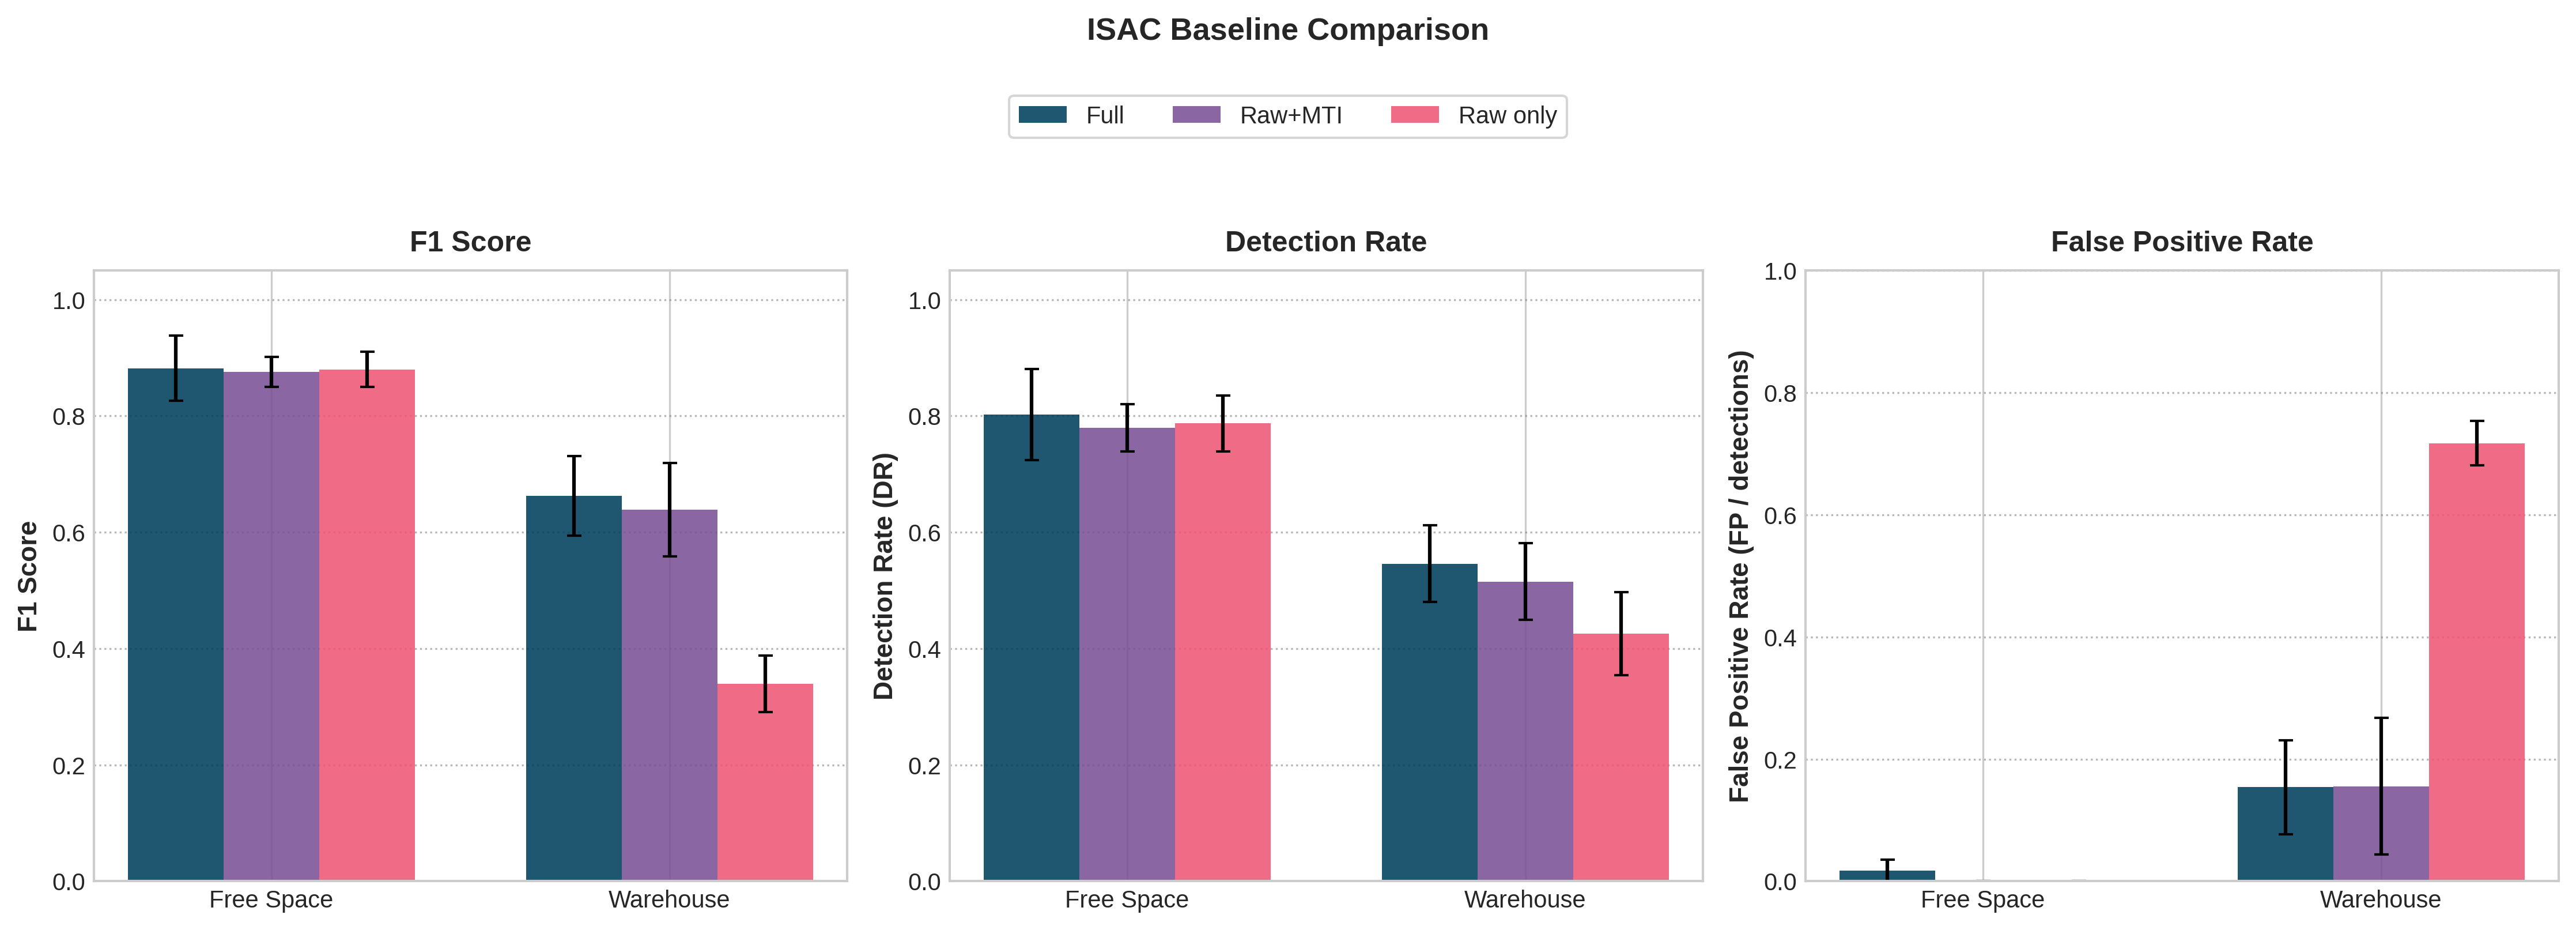

In [20]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

scene_names = ["free_space", "warehouse"]
scene_labels = {"free_space": "Free Space", "warehouse": "Warehouse"}
variant_names = baseline_variant_names
variant_labels = {
    "Full pipeline (MTI + tracker)": "Full",
    "Raw detection + MTI": "Raw+MTI",
    "Raw detection only": "Raw only",
}
variant_colors = {
    "Full pipeline (MTI + tracker)": "#003f5c",
    "Raw detection + MTI": "#7a5195",
    "Raw detection only": "#ef5675",
}
metric_specs = [
    ("f1", "F1 Score", "F1 Score", (0.0, 1.05)),
    ("dr", "Detection Rate (DR)", "Detection Rate", (0.0, 1.05)),
    ("fpr", "False Positive Rate (FP / detections)", "False Positive Rate", (0.0, 1.0)),
]
width = 0.24
x = np.arange(len(scene_names))
variant_offsets = (np.arange(len(variant_names)) - (len(variant_names) - 1) / 2.0) * width

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.8), dpi=300, sharex=True)
for ax, (metric_key, ylabel, subplot_title, ylim) in zip(axes, metric_specs):
    for offset, variant in zip(variant_offsets, variant_names):
        means = [baseline_summary[scene][variant][f"{metric_key}_mean"] for scene in scene_names]
        stds = [baseline_summary[scene][variant][f"{metric_key}_std"] for scene in scene_names]
        ax.bar(
            x + offset,
            means,
            width,
            yerr=stds,
            capsize=3,
            color=variant_colors[variant],
            alpha=0.88,
            label=variant_labels[variant],
        )
    ax.set_title(subplot_title, fontsize=12, fontweight='bold', pad=8)
    ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([scene_labels[scene] for scene in scene_names])
    ax.set_ylim(*ylim)
    ax.grid(True, axis='y', linestyle=':', alpha=0.6, color='#888888')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    frameon=True,
    facecolor='white',
    edgecolor='#cccccc',
    ncols=3,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.03),
)
fig.suptitle("ISAC Baseline Comparison", fontsize=13, fontweight='bold', y=1.11)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))
plt.savefig("isac_baseline_comparison_metrics.png", dpi=300, bbox_inches='tight')
plt.show()


# Communication gain from ISAC-assisted beamforming

This section quantifies the communication-side benefit of the ISAC sensing loop by replaying the same mobility trace twice: once with situation-aware beamforming enabled and once with the baseline communication array. Because the exported scalar path loss intentionally excludes the ns-3 beamforming step, the gain is computed as an array-factor receive-power ratio: baseline transmit weights toward the configured/default look direction versus ISAC transmit weights toward the matched radar detection, evaluated at each paired UE link.


In [17]:
import copy
import numpy as np
import matplotlib.pyplot as plt

COMM_GAIN_SCENES = {
    "free_space": {
        "label": "Free Space",
        "radio": radio_settings,
        "mobility": mobility_settings,
        "waypoints": UE_WAYPOINTS,
        "duration_s": 8.0,
    },
    "warehouse": {
        "label": "Warehouse",
        "radio": wh_radio_settings,
        "mobility": wh_mobility_settings,
        "waypoints": WH_WAYPOINTS,
        "duration_s": 8.0,
    },
}
COMM_GAIN_SAMPLES_PER_SRC = 500_000
COMM_GAIN_MAX_DEPTH = 1
COMM_GAIN_NUM_SUBCARRIERS = 12


def _make_comm_gain_trace(radio_cfg, mobility_cfg, waypoints, duration_s):
    trace_mobility = SionnaMobility()
    trace_mobility.initialize(copy.deepcopy(mobility_cfg))

    names = list(radio_cfg["rx_names"])
    dt = float(radio_cfg["rx_update_interval"])
    rx_height = float(radio_cfg["rx_locations"][0][2])
    num_steps = max(1, int(float(duration_s) / dt))
    wp_idx = {name: 1 for name in names}
    current_dest = {}

    for name in names:
        first_dest = waypoints[name][1]
        current_dest[name] = first_dest
        trace_mobility.set_destination(name, [first_dest[0], first_dest[1], 0.0])

    trace = []
    for step in range(num_steps):
        timestamp = step * dt
        frame = {"time": timestamp, "positions": {}}
        for name in names:
            pos = trace_mobility.update_position(name, timestamp)
            if pos is None:
                continue
            frame["positions"][name] = [pos[0], pos[1], rx_height]
            dest = current_dest[name]
            if np.hypot(pos[0] - dest[0], pos[1] - dest[1]) < 1.5:
                nxt = _advance_wp(name, waypoints, wp_idx)
                trace_mobility.set_destination(name, [nxt[0], nxt[1], 0.0])
                current_dest[name] = nxt
        trace.append(frame)
    return trace


def _run_comm_gain_variant(radio_cfg, trace, enable_isac):
    cfg = copy.deepcopy(radio_cfg)
    cfg["enable_situation_awareness"] = bool(enable_isac)
    cfg["simulation_duration"] = trace[-1]["time"] + float(radio_cfg["rx_update_interval"])
    cfg["rx_locations"] = [trace[0]["positions"][name] for name in cfg["rx_names"]]
    cfg["num_subcarriers"] = COMM_GAIN_NUM_SUBCARRIERS
    cfg["adaptive_future_max_steps"] = 0
    cfg["isac_samples_per_src"] = COMM_GAIN_SAMPLES_PER_SRC
    cfg["isac_max_depth"] = COMM_GAIN_MAX_DEPTH
    cfg["isac_diffuse_reflection"] = True
    cfg["isac_single_bounce_only"] = True
    cfg["isac_tracker_max_tracks"] = max(10, len(cfg["rx_names"]))
    cfg.pop("isac_mti_dist_threshold", None)

    rt = SionnaRT()
    rt.initialize(cfg)

    records = []
    for frame in trace:
        for name, pos in frame["positions"].items():
            rt.update_position(name, pos)
        for rec in rt.perform_calculation(frame["time"]):
            if rec["dst_id"] not in cfg["rx_ids"]:
                continue
            rec = dict(rec)
            rec["time"] = float(frame["time"])
            records.append(rec)

    return records, rt.get_detected_objects(), rt.get_perf_stats()


def _index_link_records(records):
    indexed = {}
    for rec in records:
        key = (round(float(rec["time"]), 9), int(rec["dst_id"]))
        indexed[key] = rec
    return indexed




def _record_tx_element_count(rec, fallback_count):
    tx_elems = int(rec.get("mimo_tx_elems", 0) or 0)
    return tx_elems if tx_elems > 0 else int(fallback_count)


def _array_positions(num_rows, num_cols, v_spacing, h_spacing):
    rows = np.arange(num_rows, dtype=float) - (num_rows - 1) / 2.0
    cols = np.arange(num_cols, dtype=float) - (num_cols - 1) / 2.0
    return np.asarray([[0.0, c * h_spacing, r * v_spacing] for r in rows for c in cols], dtype=float)


def _direction_unit(src_pos, dst_pos):
    vec = np.asarray(dst_pos, dtype=float) - np.asarray(src_pos, dtype=float)
    norm = float(np.linalg.norm(vec))
    if norm <= 1e-12:
        return np.array([1.0, 0.0, 0.0])
    return vec / norm


def _array_response(num_rows, num_cols, v_spacing, h_spacing, wavelength, src_pos, dst_pos):
    elem_pos = _array_positions(num_rows, num_cols, v_spacing, h_spacing)
    direction = _direction_unit(src_pos, dst_pos)
    phase = 2.0 * np.pi / float(wavelength) * (elem_pos @ direction)
    return np.exp(1j * phase)


def _steering_weights(num_rows, num_cols, v_spacing, h_spacing, wavelength, src_pos, dst_pos):
    response = _array_response(num_rows, num_cols, v_spacing, h_spacing, wavelength, src_pos, dst_pos)
    return np.conjugate(response) / np.sqrt(response.size)


def _fit_vector_to_tx_elems(vector, tx_elems):
    values = np.asarray(vector, dtype=np.complex128)
    if values.size == tx_elems:
        return values
    if tx_elems % values.size == 0:
        values = np.tile(values, tx_elems // values.size)
    else:
        values = np.resize(values, tx_elems)
    return values


def _fit_weights_to_tx_elems(weights, tx_elems):
    values = _fit_vector_to_tx_elems(weights, tx_elems)
    norm = float(np.linalg.norm(values))
    if norm <= 1e-12:
        return values
    return values / norm


def _beam_array_gain_linear(rec, tx_weights, radio_cfg, tx_rows, tx_cols, v_spacing, h_spacing, wavelength, tx_pos):
    tx_elems = _record_tx_element_count(rec, tx_rows * tx_cols)
    response = _array_response(
        tx_rows,
        tx_cols,
        v_spacing,
        h_spacing,
        wavelength,
        tx_pos,
        rec["rx_position"],
    )
    response = _fit_vector_to_tx_elems(response, tx_elems)
    weights = _fit_weights_to_tx_elems(tx_weights, tx_elems)
    element_gain = abs(np.vdot(np.conjugate(response), weights)) ** 2
    return max(float(element_gain), 1e-300)


def _beam_rx_power_dbm(rec, tx_weights, radio_cfg, tx_rows, tx_cols, v_spacing, h_spacing, wavelength, tx_pos):
    tx_power_dbm = float(radio_cfg.get("tx_power", 46.0))
    wideband_rx_power = tx_power_dbm - float(rec["path_loss"])
    beam_gain_db = 10.0 * np.log10(
        _beam_array_gain_linear(rec, tx_weights, radio_cfg, tx_rows, tx_cols, v_spacing, h_spacing, wavelength, tx_pos)
    )
    return wideband_rx_power + beam_gain_db


def _matched_detection_for_link(detections_by_time, time_s, rx_pos, max_match_m=3.0):
    positions = detections_by_time.get(round(float(time_s), 9), [])
    if not positions:
        return None
    rx_pos = np.asarray(rx_pos, dtype=float)
    dets = np.asarray(positions, dtype=float)
    dists = np.linalg.norm(dets - rx_pos[None, :], axis=1)
    best = int(np.argmin(dists))
    if float(dists[best]) > max_match_m:
        return None
    return dets[best]


def _summarize_comm_gain(baseline_records, isac_records, detections, radio_cfg):
    baseline_by_link = _index_link_records(baseline_records)
    isac_by_link = _index_link_records(isac_records)
    detections_by_time = {
        round(float(frame["time"]), 9): frame["positions"]
        for frame in detections
    }
    active_times = {t for t, positions in detections_by_time.items() if positions}

    fc = float(radio_cfg["carrier_frequency"])
    wavelength = 299_792_458.0 / fc
    tx_rows = int(radio_cfg.get("tx_num_rows", 8))
    tx_cols = int(radio_cfg.get("tx_num_cols", 8))
    v_spacing = float(radio_cfg.get("vertical_array_spacing", wavelength / 2.0))
    h_spacing = float(radio_cfg.get("horizontal_array_spacing", wavelength / 2.0))
    tx_pos = np.asarray(radio_cfg["tx_locations"][0], dtype=float)
    baseline_target = np.asarray(radio_cfg.get("tx_look_at", [[tx_pos[0] + 1.0, tx_pos[1], tx_pos[2]]])[0], dtype=float)
    baseline_weights = _steering_weights(tx_rows, tx_cols, v_spacing, h_spacing, wavelength, tx_pos, baseline_target)

    rows = []
    for key in sorted(set(baseline_by_link) & set(isac_by_link)):
        base = baseline_by_link[key]
        assisted = isac_by_link[key]
        time_s, dst_id = key
        rx_pos = np.asarray(assisted["rx_position"], dtype=float)
        det_pos = _matched_detection_for_link(detections_by_time, time_s, rx_pos)
        beam_target = det_pos if det_pos is not None else baseline_target
        isac_weights = _steering_weights(tx_rows, tx_cols, v_spacing, h_spacing, wavelength, tx_pos, beam_target)

        base_rx_dbm = _beam_rx_power_dbm(
            base, baseline_weights, radio_cfg, tx_rows, tx_cols, v_spacing, h_spacing, wavelength, tx_pos
        )
        isac_rx_dbm = _beam_rx_power_dbm(
            assisted, isac_weights, radio_cfg, tx_rows, tx_cols, v_spacing, h_spacing, wavelength, tx_pos
        )
        rows.append({
            "time": float(time_s),
            "dst_id": int(dst_id),
            "baseline_rx_power_dbm": base_rx_dbm,
            "isac_rx_power_dbm": isac_rx_dbm,
            "gain_db": isac_rx_dbm - base_rx_dbm,
            "beam_active": time_s in active_times and det_pos is not None,
            "matched_detection": None if det_pos is None else det_pos.tolist(),
        })
    return rows


COMM_GAIN_METRIC_VERSION = "array_factor_v2"
print(f"Communication-gain metric: {COMM_GAIN_METRIC_VERSION}")

comm_gain_results = {}
for scene_name, spec in COMM_GAIN_SCENES.items():
    print(f"\n=== Communication gain: {spec['label']} ===")
    trace = _make_comm_gain_trace(spec["radio"], spec["mobility"], spec["waypoints"], spec["duration_s"])
    baseline_records, _, baseline_perf = _run_comm_gain_variant(spec["radio"], trace, enable_isac=False)
    isac_records, isac_detections, isac_perf = _run_comm_gain_variant(spec["radio"], trace, enable_isac=True)
    rows = _summarize_comm_gain(
        baseline_records,
        isac_records,
        isac_detections,
        spec["radio"],
    )

    gains = np.asarray([row["gain_db"] for row in rows], dtype=float)
    active_gains = np.asarray([row["gain_db"] for row in rows if row["beam_active"]], dtype=float)
    comm_gain_results[scene_name] = {
        "label": spec["label"],
        "rows": rows,
        "baseline_records": baseline_records,
        "isac_records": isac_records,
        "detections": isac_detections,
        "baseline_perf": baseline_perf,
        "isac_perf": isac_perf,
    }

    print(f"Paired links       : {len(rows)}")
    print(f"Beam-active frames : {sum(1 for frame in isac_detections if frame['positions'])}/{len(isac_detections)}")
    print(f"Mean gain          : {gains.mean():.2f} dB" if gains.size else "Mean gain          : n/a")
    print(f"Median gain        : {np.median(gains):.2f} dB" if gains.size else "Median gain        : n/a")
    print(f"Beam-active gain   : {active_gains.mean():.2f} dB" if active_gains.size else "Beam-active gain   : n/a")


Communication-gain metric: array_factor_v2

=== Communication gain: Free Space ===
Paired links       : 48
Beam-active frames : 14/16
Mean gain          : 31.54 dB
Median gain        : 31.29 dB
Beam-active gain   : 36.04 dB

=== Communication gain: Warehouse ===
Paired links       : 48
Beam-active frames : 15/16
Mean gain          : 10.01 dB
Median gain        : 10.08 dB
Beam-active gain   : 10.67 dB


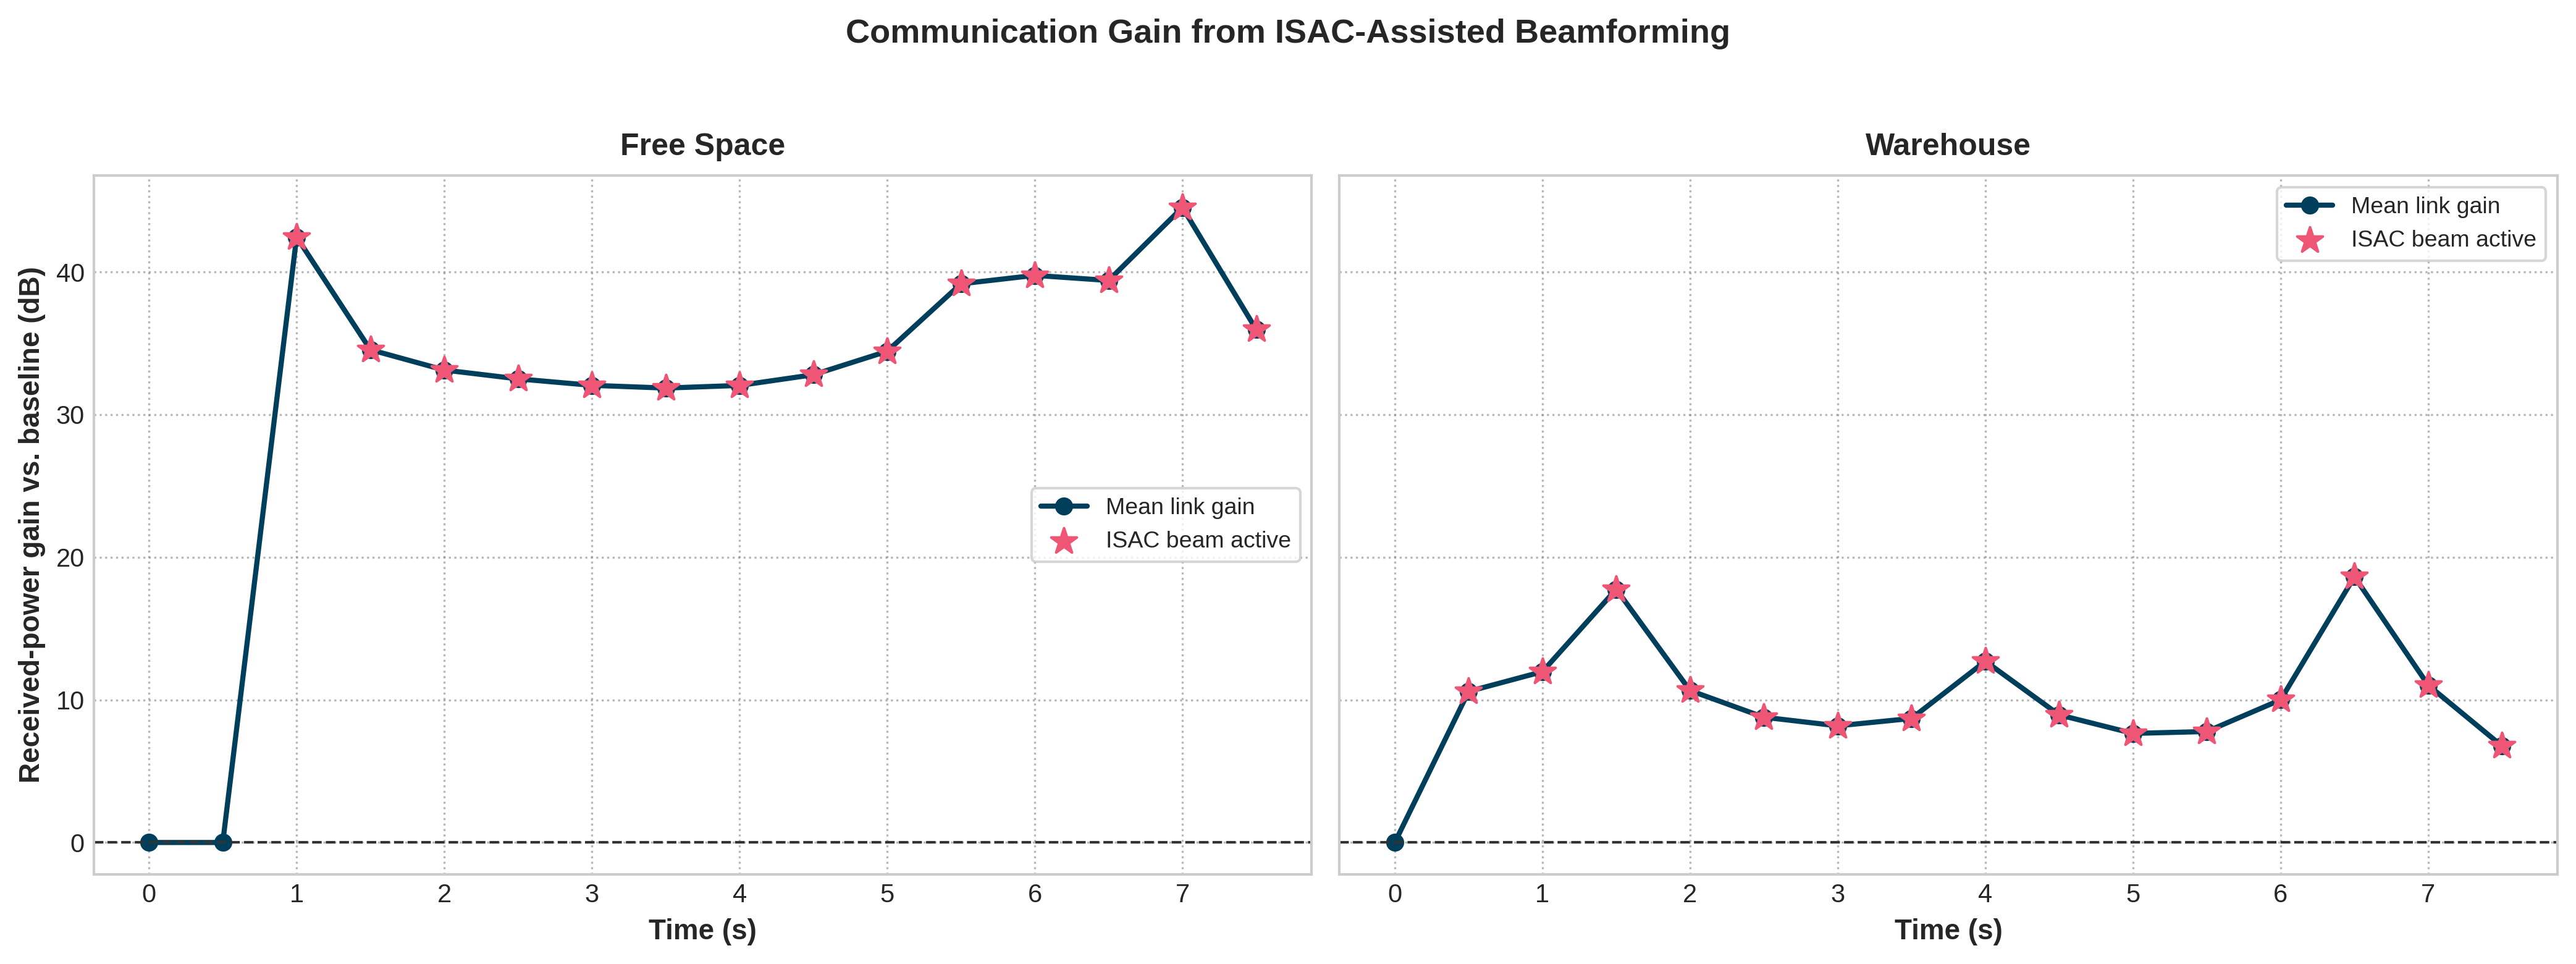

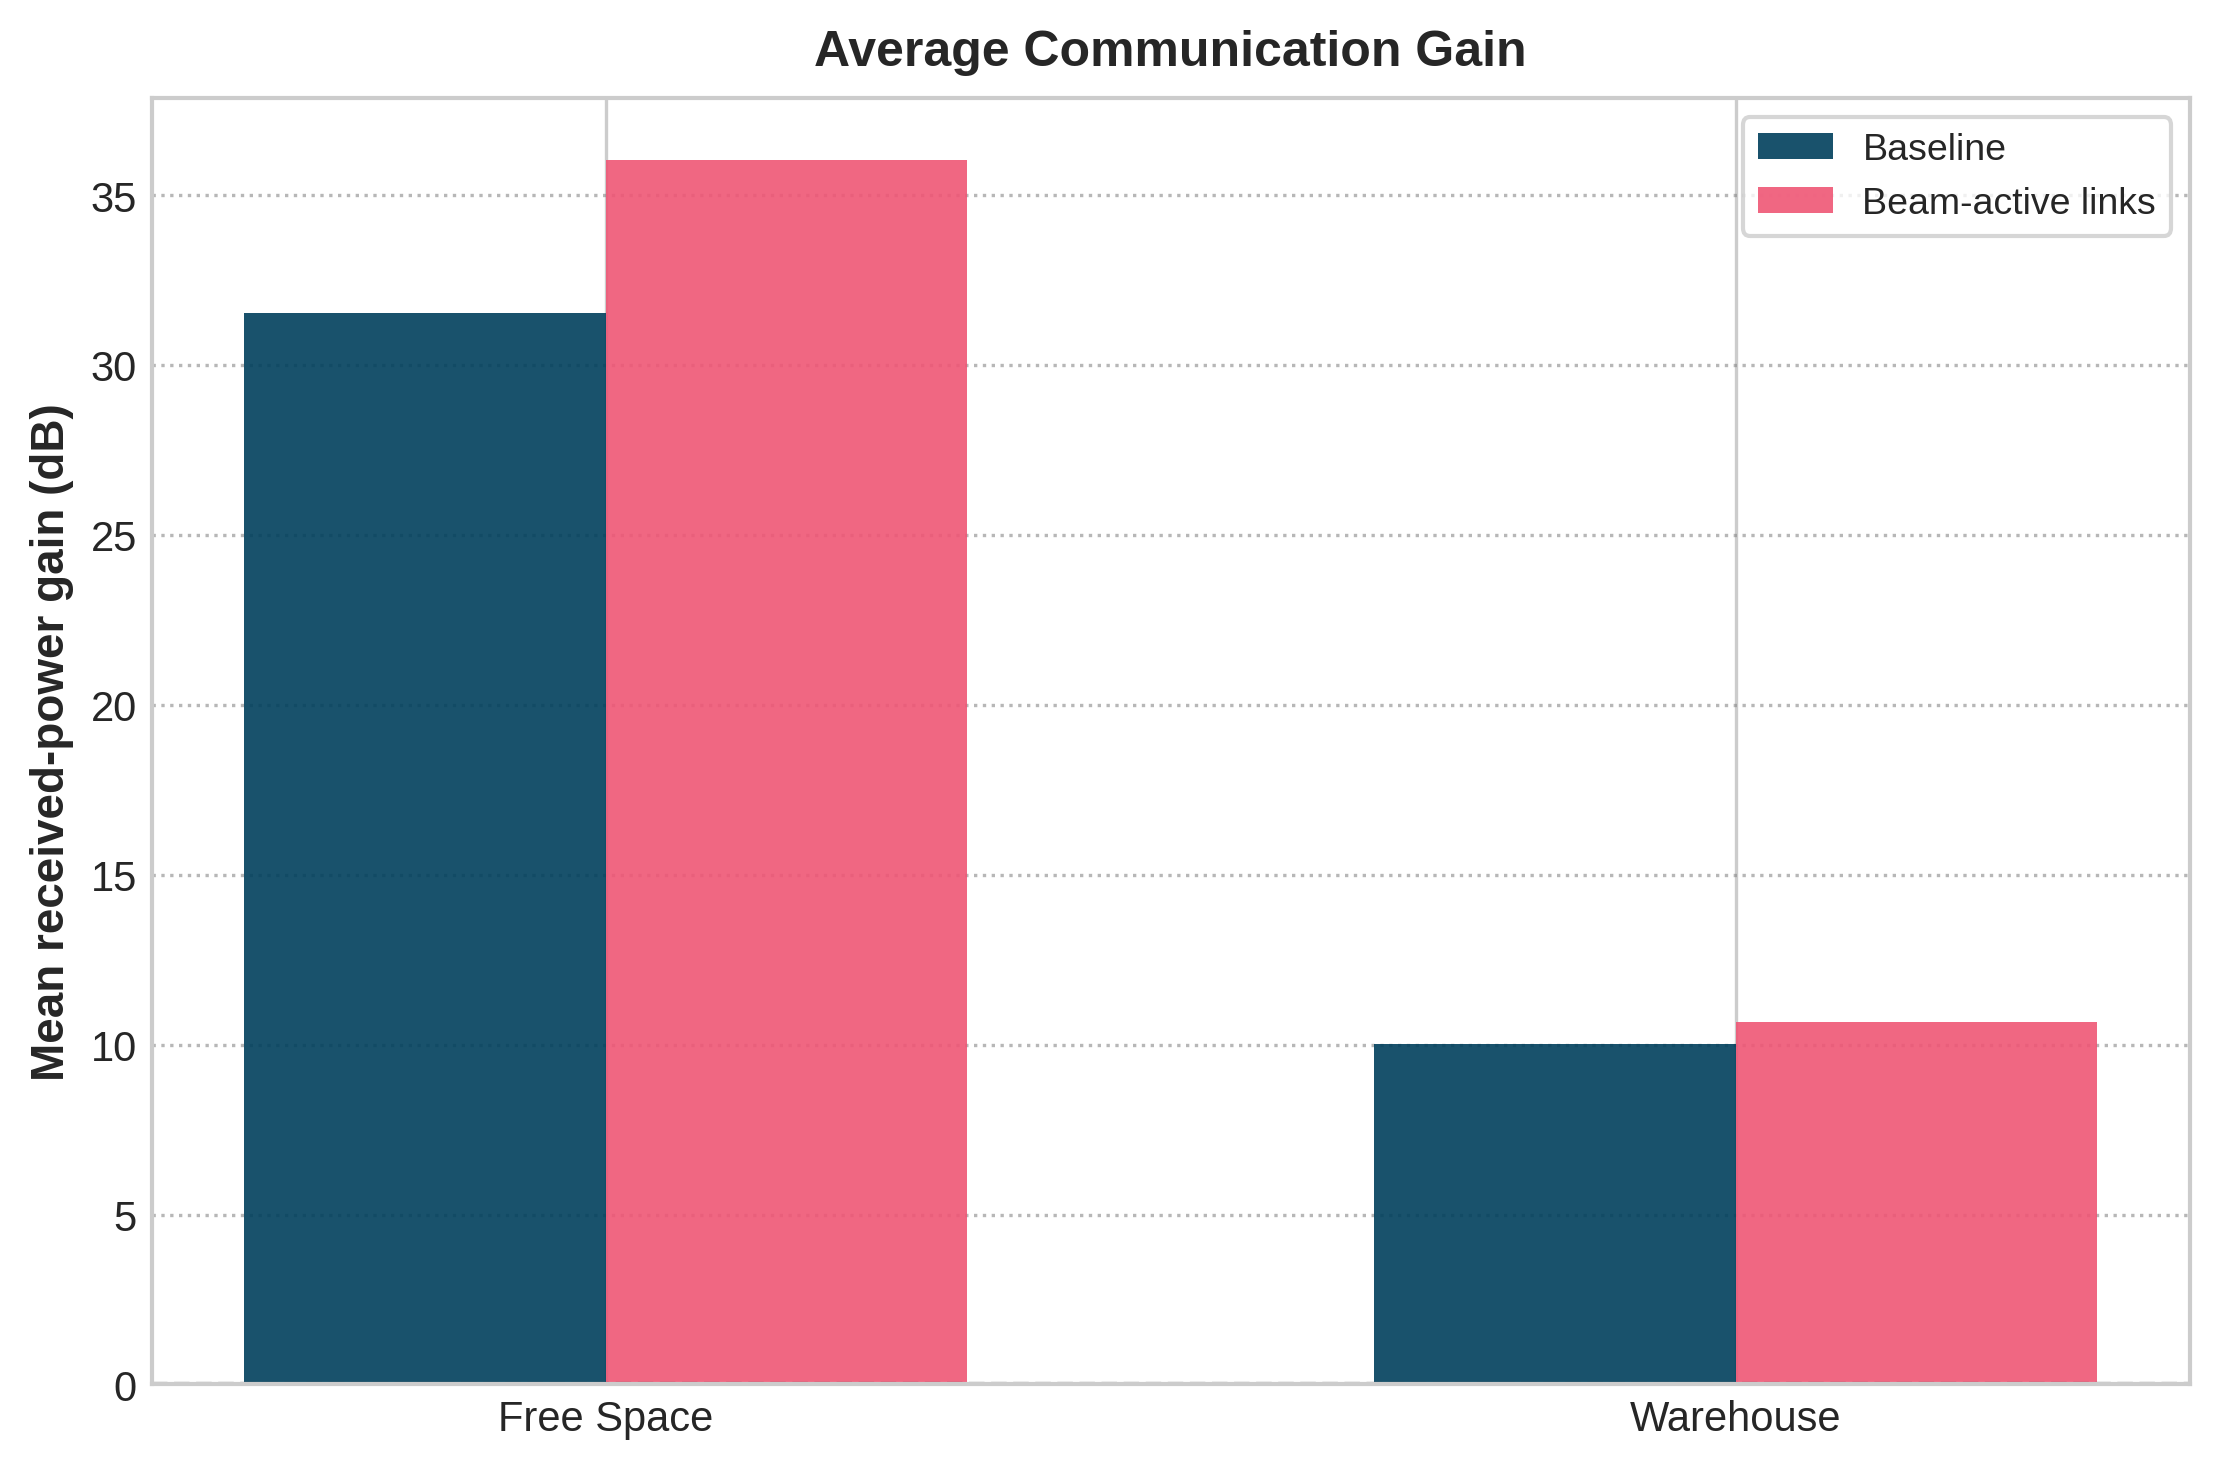

In [19]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

fig, axes = plt.subplots(1, len(comm_gain_results), figsize=(7.0 * len(comm_gain_results), 5.0), dpi=300, sharey=True)
if len(comm_gain_results) == 1:
    axes = [axes]

for ax, (scene_name, result) in zip(axes, comm_gain_results.items()):
    rows = result["rows"]
    times = sorted({row["time"] for row in rows})
    mean_gain = [np.mean([row["gain_db"] for row in rows if row["time"] == t]) for t in times]
    active_times = {row["time"] for row in rows if row["beam_active"]}

    ax.plot(times, mean_gain, marker='o', linewidth=2, color='#003f5c', label="Mean link gain")
    if active_times:
        active_y = [mean_gain[i] for i, t in enumerate(times) if t in active_times]
        active_x = [t for t in times if t in active_times]
        ax.scatter(active_x, active_y, marker='*', s=110, color='#ef5675', label="ISAC beam active", zorder=4)
    ax.axhline(0.0, color='#333333', linestyle='--', linewidth=1)
    ax.set_title(f"{result['label']}", fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel("Time (s)", fontsize=11, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6, color='#888888')
    ax.legend(loc='best', frameon=True, facecolor='white', edgecolor='#cccccc', fontsize=9)

axes[0].set_ylabel("Received-power gain vs. baseline (dB)", fontsize=11, fontweight='bold')
fig.suptitle("Communication Gain from ISAC-Assisted Beamforming", fontsize=13, fontweight='bold', y=1.03)
fig.tight_layout()
plt.savefig("isac_assisted_beamforming_communication_gain.png", dpi=300, bbox_inches='tight')
plt.show()

scene_labels = [result["label"] for result in comm_gain_results.values()]
mean_gains = [np.mean([row["gain_db"] for row in result["rows"]]) for result in comm_gain_results.values()]
active_mean_gains = [
    np.mean([row["gain_db"] for row in result["rows"] if row["beam_active"]])
    if any(row["beam_active"] for row in result["rows"]) else np.nan
    for result in comm_gain_results.values()
]

x = np.arange(len(scene_labels))
width = 0.32
fig, ax = plt.subplots(figsize=(7.5, 5.0), dpi=300)
ax.bar(x - width / 2, mean_gains, width, color='#003f5c', alpha=0.9, label="Baseline")
ax.bar(x + width / 2, active_mean_gains, width, color='#ef5675', alpha=0.9, label="Beam-active links")
ax.axhline(0.0, color='#333333', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(scene_labels)
ax.set_ylabel("Mean received-power gain (dB)", fontsize=11, fontweight='bold')
ax.set_title("Average Communication Gain", fontsize=12, fontweight='bold', pad=8)
ax.legend(loc='best', frameon=True, facecolor='white', edgecolor='#cccccc', fontsize=9)
ax.grid(True, axis='y', linestyle=':', alpha=0.6, color='#888888')
fig.tight_layout()
plt.savefig("isac_assisted_beamforming_average_gain.png", dpi=300, bbox_inches='tight')
plt.show()
